# Notebook GNN Spatial Électrique
Prédiction de `p` (production par bus générateur) sur les **24 prochaines heures**
à partir des **72 heures passées** de charge et de vent, et de la **structure spatiale du réseau HT belge**.

- **Modèle purement spatial** (encodeur MLP → message passing GINEConv → décodeur MLP)
- **45 bus**, **65 lignes**, **24 générateurs** → production agrégée sur **15 bus générateurs**
- Même architecture et pipeline que le notebook gaz de référence


In [1]:
# ============================================================
# Cellule 1 - Installation / vérification de PyTorch Geometric
# ============================================================
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name: str, pip_name: str | None = None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installation de {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} déjà installé.")

ensure_package("torch_geometric", "torch-geometric")


torch_geometric déjà installé.


In [81]:
# ============================================================
# Cellule 2 - Hyperparamètres / constantes / chemins
# ============================================================
from pathlib import Path

CONFIG = {
    # ── chemins ───────────────────────────────────────────────────
    "BASE_DIR"      : Path("."),
    "PATH_NETWORK"  : Path("./Elec Network Data.xlsx"),
    "PATH_WIND"     : Path("./input/Wind Data.xlsx"),
    "PATH_LOAD"     : Path("./input/Elec Load Data.xlsx"),
    "PATH_DECISION" : Path("./output/Decision_variablesRU.xlsx"),

    # ── structure problème ────────────────────────────────────────
    "MONTHS"   : [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 45,
    # Bus avec au moins un générateur (0-based)
    # Dérivé de GenMap : buses 7,13,15,16,19,27,28,29,33,36,38,40,42,44,45 (1-based)
    "GENERATOR_BUS_IDX": [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44],
    "NUM_GENERATORS": 24,

    # ── fenêtres temporelles ──────────────────────────────────────
    "HIST_HOURS"    : 72,
    "HORIZON_HOURS" : 24,
    "STRIDE_HOURS"  : 24,   # stride réduit pour augmenter le nb de fenêtres d'entraînement

    # ── split temporel ────────────────────────────────────────────
    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END"  : "2024-11-01 00:00:00",

    # ── features dynamiques nodales ───────────────────────────────
    "USE_LOAD_HISTORY"         : True,   # charge nodale distribuée (MW)
    "USE_WIND_OFFSHORE_HISTORY": True,   # vent offshore (MW, seulement bus 38 = STEVN)
    "USE_WIND_ONSHORE_HISTORY" : True,   # vent onshore distribué (MW)
    "USE_P_HISTORY"            : False,   # production historique aux bus générateurs (MW)

    # ── features statiques nodales ────────────────────────────────
    "USE_NODE_STATIC_IS_GENERATOR"   : True,
    "USE_NODE_STATIC_GENERATOR_COUNT": True,
    "USE_NODE_STATIC_PMAX_TOTAL"     : True,
    "USE_NODE_STATIC_LOAD_SHARE"     : True,
    "USE_NODE_STATIC_PV_SHARE"       : True,
    "USE_NODE_STATIC_ONSHORE_SHARE"  : True,
    "USE_NODE_STATIC_IS_OFFSHORE"    : True,
    "USE_NODE_STATIC_IS_IMPORT"      : True,
    "USE_NODE_STATIC_IMPORT_PMAX"    : True,
    "USE_NODE_STATIC_VOLTAGE_KV"     : True,
    "USE_NODE_STATIC_IS_TRANSFER"    : True,
    "USE_NODE_STATIC_DEGREE"         : True,

    # ── features statiques d'arête ────────────────────────────────
    "EDGE_STATIC_COLUMNS": [
        "X_pu",
        "b_pu",
        "Pmax_MW",
        "Length_km",
        "Inom_A",
        "UB_kV",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    # ── modèle ────────────────────────────────────────────────────
    "MODEL_TYPE"          : "gine",
    "HIDDEN_DIM"          : 12,
    "ENCODER_HIDDEN_DIMS" : [8,4],
    "DECODER_HIDDEN_DIMS" : [4,8],
    "NUM_MP_LAYERS"       : 3,
    "DROPOUT"             : 0.05,
    "USE_BATCHNORM"       : True,
    "RESIDUAL"            : True,

    # ── entraînement ──────────────────────────────────────────────
    "SEED"                   : 42,
    "DEVICE"                 : "cpu",
    "EPOCHS"                 : 200,
    "BATCH_SIZE"             : 24,
    "LR"                     : 3e-4,
    "WEIGHT_DECAY"           : 1e-4,
    "GRAD_CLIP_NORM"         : 2.0,
    "EARLY_STOPPING_PATIENCE": 30,
    "EARLY_STOPPING_MIN_DELTA": 1e-4,
    "SCHEDULER_FACTOR"       : 0.4,
    "SCHEDULER_PATIENCE"     : 6,
    "SCHEDULER_MIN_LR"       : 1e-6,

    # ── divers ────────────────────────────────────────────────────
    "PERSISTENCE_MODE"     : "last_24h",
    "NUM_ALIGNMENT_CHECKS" : 5,
    "SAVE_MODEL_STATE"     : False,
    "MODEL_STATE_PATH"     : Path("spatial_elec_gnn.pt"),
}

PATHS = {
    "network" : CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "wind"    : CONFIG["BASE_DIR"] / CONFIG["PATH_WIND"],
    "load"    : CONFIG["BASE_DIR"] / CONFIG["PATH_LOAD"],
    "decision": CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")
for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"
print("\nCONFIG OK.")


Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Elec Network Data.xlsx | exists=True
  wind: C:\Users\yoans\TFE - GAZ\input\Wind Data.xlsx | exists=True
  load: C:\Users\yoans\TFE - GAZ\input\Elec Load Data.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.


In [82]:
# ============================================================
# Cellule 3 - Imports, seed, utilitaires de base
# ============================================================
import copy
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df: pd.DataFrame) -> pd.DataFrame:
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


DEVICE = cpu


In [83]:
# ============================================================
# Cellule 4 - Lecture des données statiques du réseau électrique
# ============================================================
buses_df    = pd.read_excel(PATHS["network"], sheet_name="Buses")
lines_df    = pd.read_excel(PATHS["network"], sheet_name="LinesMerged")
gen_df      = pd.read_excel(PATHS["network"], sheet_name="Gen")
genmap_df   = pd.read_excel(PATHS["network"], sheet_name="GenMap", header=0)
windmap_df  = pd.read_excel(PATHS["network"], sheet_name="WindMap", header=0)
impmap_df   = pd.read_excel(PATHS["network"], sheet_name="ImpMap", header=0)
imp_df      = pd.read_excel(PATHS["network"], sheet_name="Imp")
renew_df    = pd.read_excel(PATHS["network"], sheet_name="Renew")

num_nodes = CONFIG["NUM_NODES"]
generator_bus_idx = CONFIG["GENERATOR_BUS_IDX"]  # 0-based

pretty_shape("buses_df",   buses_df)
pretty_shape("lines_df",   lines_df)
pretty_shape("gen_df",     gen_df)
pretty_shape("genmap_df",  genmap_df)
pretty_shape("windmap_df", windmap_df)
pretty_shape("impmap_df",  impmap_df)

assert len(buses_df) == num_nodes, f"Attendu {num_nodes} bus, trouvé {len(buses_df)}"
assert len(gen_df) == CONFIG["NUM_GENERATORS"], \
    f"Attendu {CONFIG['NUM_GENERATORS']} générateurs, trouvé {len(gen_df)}"
assert genmap_df.shape == (num_nodes, CONFIG["NUM_GENERATORS"]), \
    f"GenMap shape inattendue: {genmap_df.shape}"
assert windmap_df.shape[0] == num_nodes

print("\nColonnes Buses  :", list(buses_df.columns))
print("Colonnes Lines  :", list(lines_df.columns))
print("Colonnes Gen    :", list(gen_df.columns))
print()
display(buses_df.head())
display(lines_df.head())
display(gen_df)


buses_df: shape=(45, 9)
lines_df: shape=(65, 18)
gen_df: shape=(24, 14)
genmap_df: shape=(45, 24)
windmap_df: shape=(45, 1)
impmap_df: shape=(45, 8)

Colonnes Buses  : ['Node', 'Name', 'Province', 'Type', 'UB_kV', 'Transfos', 'Load_share_%', 'Pv_share_%', 'Onshore_share_%']
Colonnes Lines  : ['Line', 'FromNode', 'ToNode', 'FromNodeName', 'ToNodeName', 'UB_kV', 'Length_km', 'Inom_A', 'R_ohm', 'X_ohm', 'b_S', 'Zb', 'b_pu', 'X_pu', 'wC_µS', 'Pmax_MW', 'Lat_from', 'Long_from']
Colonnes Gen    : ['Generator', 'Name', 'NodeName', 'Node', 'Gas node', 'Pmin_MW', 'Pmax_MW', 'Type', 'Fuel', 'Ramp rate [%/h]', 'Efficiency', 'VOM_€/MWh', 'FuelCost_€/MWh_fuel', 'Year ']



,Node,Name,Province,Type,UB_kV,Transfos,Load_share_%,Pv_share_%,Onshore_share_%
0,1,ACHEN,Namur,Load,380,270,1.541360,1.727500,5.799500
1,2,AUBAN220,Luxembourg,Load,220,240,1.370098,0.548000,0.864750
2,3,AUBAN380,Luxembourg,Load,380,30,0.171262,0.000000,0.000000
3,4,AVLGM,WV,Load,380,1035,5.908546,8.010000,4.370500
4,5,AWIRS,Liege,Load,220,560,3.196894,0.644818,0.893182


,Line,FromNode,ToNode,FromNodeName,ToNodeName,UB_kV,Length_km,Inom_A,R_ohm,X_ohm,b_S,Zb,b_pu,X_pu,wC_µS,Pmax_MW,Lat_from,Long_from
0,1,1,17,ACHEN,GRAMM,380,36.9,1999,1.140000,12.100000,0.082645,1444,119.338843,0.008380,141.47,1315.700434,50.267829,5.045634
1,2,3,8,AUBAN380,BRUME,380,104.4,2186,3.550000,32.880000,0.030414,1444,43.917275,0.022770,379.36,1438.779965,49.563838,5.799276
2,3,4,18,AVLGM,HORTA,380,39.7,4185,0.620008,6.505001,0.153728,1444,221.983221,0.004505,299.85,2754.480399,50.774131,3.445316
3,4,4,19,AVLGM,IZGEM,380,22.8,4372,0.355000,3.740000,0.267380,1444,386.096257,0.002590,175.30,2877.559930,50.774131,3.445316
4,5,7,28,BRUEG,MEKI+,380,14,1999,0.450000,4.630000,0.215983,1444,311.879050,0.003206,54.18,1315.700434,50.838519,4.262445


,Generator,Name,NodeName,Node,Gas node,Pmin_MW,Pmax_MW,Type,Fuel,Ramp rate [%/h],Efficiency,VOM_€/MWh,FuelCost_€/MWh_fuel,Year
0,1,Vilvoorde GT,VERBR,42,13.0,0,360.0,CCGT-GT,Gas,0.5,0.52,2.0,0.00,2001.0
1,2,Syral Aalst GT,BRUEG,7,24.0,0,48.0,CCGT-GT (CHP),Gas,0.5,0.45,3.3,0.00,2000.0
2,3,DOEL 1-2-4,DOEL,13,NaN,0,1929.0,NU,Uranium,0.1,0.33,9.0,1.87,NaN
3,4,HERDERSBRUG,GEZEL,15,2.0,0,480.3,CCGT-GT,Gas,0.5,0.51,2.0,0.00,1998.0
4,5,Fluxys LNG Zeebrugge WKK,GEZEL,15,2.0,0,40.0,OCGT (CHP),Gas,0.5,0.45,15.0,0.00,1987.0
5,6,Marcinelle + Saint-Ghi + Amercoeur,GOUY,16,27.0,0,1242.0,CCGT,Gas,0.5,0.54,2.0,0.00,2001.0
6,7,IZEGEM,IZGEM,19,3.0,0,20.0,CCGT (CHP),Gas,0.5,0.34,15.0,0.00,1995.0
7,8,T-Power,MEERH,27,11.0,0,425.0,CCGT,Gas,1.0,0.58,2.0,0.00,2011.0
8,9,DROGENBOS,MEKI+,28,24.0,0,460.0,CCGT-GT,Gas,0.5,0.52,2.0,0.00,1993.0
9,10,Borealis + Scheldelaan,MERCA,29,8.0,0,172.0,CCGT (CHP),Gas,0.6,0.45,3.3,0.00,2009.0


In [84]:
# ============================================================
# Cellule 5 - Construction du mapping générateur → bus
#              et features statiques nodales
# ============================================================
genmap = genmap_df.to_numpy(dtype=float)   # [45, 24]

# ── mapping gen_idx (0-based) → bus_idx (0-based) ──────────
generator_to_bus = {}
for gen_idx in range(CONFIG["NUM_GENERATORS"]):
    connected_buses = np.where(genmap[:, gen_idx] > 0.5)[0]
    assert len(connected_buses) == 1, \
        f"Gen {gen_idx} connecté à {len(connected_buses)} bus (attendu 1)"
    generator_to_bus[gen_idx] = int(connected_buses[0])

print("Mapping gen → bus (0-based):")
for g, b in generator_to_bus.items():
    print(f"  Gen{g+1:2d} → Bus {b+1:2d} ({buses_df.iloc[b]['Name']})")

# ── Pmax par bus ────────────────────────────────────────────
pmax_per_bus = np.zeros(num_nodes, dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    pmax_val = gen_df.iloc[gen_idx]["Pmax_MW"]
    if isinstance(pmax_val, str):   # certaines valeurs sont des formules Excel
        # ex: "=1039+445+445"
        pmax_val = eval(pmax_val.replace("=", ""))
    pmax_per_bus[bus_idx] += float(pmax_val)

# ── Nombre de générateurs par bus ──────────────────────────
gen_count_per_bus = np.zeros(num_nodes, dtype=int)
for gen_idx, bus_idx in generator_to_bus.items():
    gen_count_per_bus[bus_idx] += 1

# ── Validation : les bus générateurs correspondent bien à CONFIG ─
gen_buses_from_map = sorted(set(generator_to_bus.values()))
assert gen_buses_from_map == sorted(CONFIG["GENERATOR_BUS_IDX"]), \
    f"Mismatch: {gen_buses_from_map} vs {CONFIG['GENERATOR_BUS_IDX']}"
print(f"\n{len(gen_buses_from_map)} bus générateurs (0-based): {gen_buses_from_map}")

# ── WindMap : bus avec vent offshore ───────────────────────
windmap = windmap_df.to_numpy(dtype=float).flatten()   # [45]
offshore_bus_idx = np.where(windmap > 0.5)[0]
assert len(offshore_bus_idx) == 1 and offshore_bus_idx[0] == 38, \
    f"Bus offshore attendu : bus 38 (STEVN), trouvé : {offshore_bus_idx}"
print(f"Bus offshore : bus {offshore_bus_idx[0]} (STEVN), windmap OK")

# ── ImpMap : bus avec interconnexion ───────────────────────
impmap = impmap_df.to_numpy(dtype=float)   # [45, 8]
is_import_bus  = (impmap.sum(axis=1) > 0).astype(float)
import_pmax_mw = np.zeros(num_nodes, dtype=float)
for i in range(num_nodes):
    for j in range(8):
        if impmap[i, j] > 0.5:
            import_pmax_mw[i] += float(imp_df.iloc[j]["Pmax_MW"])

print(f"Bus d'interconnexion (1-based): {np.where(is_import_bus > 0)[0] + 1}")


Mapping gen → bus (0-based):
  Gen 1 → Bus 42 (VERBR)
  Gen 2 → Bus  7 (BRUEG)
  Gen 3 → Bus 13 (DOEL)
  Gen 4 → Bus 15 (GEZEL)
  Gen 5 → Bus 15 (GEZEL)
  Gen 6 → Bus 16 (GOUY)
  Gen 7 → Bus 19 (IZGEM)
  Gen 8 → Bus 27 (MEERH)
  Gen 9 → Bus 28 (MEKI+)
  Gen10 → Bus 29 (MERCA)
  Gen11 → Bus 29 (MERCA)
  Gen12 → Bus 29 (MERCA)
  Gen13 → Bus 29 (MERCA)
  Gen14 → Bus 29 (MERCA)
  Gen15 → Bus 33 (RODE+)
  Gen16 → Bus 33 (RODE+)
  Gen17 → Bus 33 (RODE+)
  Gen18 → Bus 33 (RODE+)
  Gen19 → Bus 36 (SERAI)
  Gen20 → Bus 36 (SERAI)
  Gen21 → Bus 38 (STAM+)
  Gen22 → Bus 40 (TIHA1)
  Gen23 → Bus 44 (ZANDV)
  Gen24 → Bus 45 (ZUTE+)

15 bus générateurs (0-based): [6, 12, 14, 15, 18, 26, 27, 28, 32, 35, 37, 39, 41, 43, 44]
Bus offshore : bus 38 (STEVN), windmap OK
Bus d'interconnexion (1-based): [ 1  2  4 16 23 30 41 44]


In [85]:
# ============================================================
# Cellule 6 - Recalcul des shares nodaux
# (les colonnes Excel contiennent des formules, pas des valeurs)
# ============================================================
transfos = buses_df["Transfos"].to_numpy(dtype=float)
load_share = transfos / transfos.sum()    # normalisé [0, 1], somme = 1

assert np.isclose(load_share.sum(), 1.0), "load_share doit sommer à 1"
print("load_share.sum() =", load_share.sum())

# Valeurs PV et onshore extraites des formules Excel (=X.XXX/N)
# Bus non listés → share = 0 (bus Transfer sans charge)
PV_SHARES_RAW = {
    1: 3.455/2,  2: 2.192/4,  4: 16.02/2,  5: 7.093/11,
    7: 15.46/3,  8: 7.093/11, 10: 3.455/2, 13: 17.37/4,
   14: 17.37/4, 16: 7.625/2, 17: 7.093/11, 19: 16.02/2,
   20: 7.093/11, 21: 17.26/4, 22: 7.093/11, 23: 7.093/11,
   25: 2.192/4, 26: 17.26/4, 27: 17.26/4,  28: 15.46/3,
   29: 17.37/4, 31: 7.093/11, 32: 7.093/11, 33: 17.37/4,
   34: 7.093/11, 35: 2.192/4, 36: 7.093/11, 38: 7.625/2,
   40: 7.093/11, 42: 15.46/3, 43: 2.192/4, 44: 17.26/4,
   45: 13.52,
}
ONSHORE_SHARES_RAW = {
    1: 11.599/2,  2: 3.459/4,  4: 8.741/2,  5: 9.825/11,
    7: 5.15/3,   8: 9.825/11, 10: 11.599/2, 13: 18.252/4,
   14: 18.252/4, 16: 17.785/2, 17: 9.825/11, 19: 8.741/2,
   20: 9.825/11, 21: 14.835/4, 22: 9.825/11, 23: 9.825/11,
   25: 3.459/4,  26: 14.835/4, 27: 14.835/4, 28: 5.15/3,
   29: 18.252/4, 31: 9.825/11, 32: 9.825/11, 33: 18.252/4,
   34: 9.825/11, 35: 3.459/4,  36: 9.825/11, 38: 17.785/2,
   40: 9.825/11, 42: 5.15/3,  43: 3.459/4,  44: 14.835/4,
   45: 10.35,
}

pv_share      = np.array([PV_SHARES_RAW.get(i+1, 0.0)      for i in range(num_nodes)], dtype=float)
onshore_share = np.array([ONSHORE_SHARES_RAW.get(i+1, 0.0) for i in range(num_nodes)], dtype=float)

# normaliser pour que les shares soient homogènes avec load_share
pv_share_norm      = pv_share / (pv_share.sum() + 1e-12)
onshore_share_norm = onshore_share / (onshore_share.sum() + 1e-12)

print("pv_share.sum()      =", pv_share.sum())
print("onshore_share.sum() =", onshore_share.sum())

display(pd.DataFrame({
    "bus_1based"   : np.arange(1, 46),
    "name"         : buses_df["Name"].to_numpy(),
    "type"         : buses_df["Type"].to_numpy(),
    "load_share"   : load_share,
    "pv_share"     : pv_share_norm,
    "onshore_share": onshore_share_norm,
    "gen_count"    : gen_count_per_bus,
    "pmax_total"   : pmax_per_bus,
    "is_import"    : is_import_bus.astype(int),
    "is_offshore"  : windmap.astype(int),
}).head(20))


load_share.sum() = 1.0
pv_share.sum()      = 99.995
onshore_share.sum() = 99.99599999999998


,bus_1based,name,type,load_share,pv_share,onshore_share,gen_count,pmax_total,is_import,is_offshore
0,1,ACHEN,Load,0.015414,0.017276,0.057997,0,0.0,1,0
1,2,AUBAN220,Load,0.013701,0.005480,0.008648,0,0.0,1,0
2,3,AUBAN380,Load,0.001713,0.000000,0.000000,0,0.0,0,0
3,4,AVLGM,Load,0.059085,0.080104,0.043707,0,0.0,1,0
4,5,AWIRS,Load,0.031969,0.006449,0.008932,0,0.0,0,0
5,6,BERN,Transfer,0.000000,0.000000,0.000000,0,0.0,0,0
6,7,BRUEG,Load,0.071930,0.051536,0.017167,1,48.0,0,0
7,8,BRUME,Load,0.016955,0.006449,0.008932,0,0.0,0,0
8,9,BUGG+,Transfer,0.000000,0.000000,0.000000,0,0.0,0,0
9,10,CHAMP,Load,0.028087,0.017276,0.057997,0,0.0,0,0


In [86]:
# ============================================================
# Cellule 7 - Helpers de lecture des séries temporelles 2024
# ============================================================
def read_decision_p(months, decision_path: Path):
    """Retourne p_full [T, 24] et ts_p [T]."""
    all_arrays = []
    for m in months:
        sheet = f"p-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet, header=0, index_col=0)
        # index_col=0 supprime la colonne d'index temporel (0,1,2,...)
        all_arrays.append(df.to_numpy(dtype=float))
    p_full = np.concatenate(all_arrays, axis=0)
    ts_p = pd.date_range("2024-01-01", periods=len(p_full), freq="h")
    return p_full, ts_p

def read_elec_load(months, load_path: Path):
    """Retourne load_total [T] (MW) et ts_load [T]."""
    dfs = []
    for m in months:
        sheet = f"{m}-2024"
        df = pd.read_excel(load_path, sheet_name=sheet, header=0, usecols=[0, 1])
        df.columns = ["datetime", "load_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "load_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["load_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])

def read_wind(months, wind_path: Path):
    """Retourne wind_total [T] (MW) et ts_wind [T]."""
    dfs = []
    for m in months:
        sheet = f"{m}-2024"
        df = pd.read_excel(wind_path, sheet_name=sheet, header=0, usecols=[0, 1])
        df.columns = ["datetime", "wind_MW"]
        df["datetime"] = pd.to_datetime(df["datetime"])
        dfs.append(df[["datetime", "wind_MW"]])
    df_all = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)
    return df_all["wind_MW"].to_numpy(dtype=float), pd.DatetimeIndex(df_all["datetime"])


In [87]:
# ============================================================
# Cellule 8 - Lecture et concaténation des séries 2024
# ============================================================
MONTHS = CONFIG["MONTHS"]

p_full,     ts_p    = read_decision_p(MONTHS, PATHS["decision"])
load_total, ts_load = read_elec_load(MONTHS, PATHS["load"])
wind_total, ts_wind = read_wind(MONTHS, PATHS["wind"])

# Vérifications temporelles
assert len(ts_p) == len(ts_load) == len(ts_wind), \
    f"Longueurs différentes: p={len(ts_p)}, load={len(ts_load)}, wind={len(ts_wind)}"
assert p_full.shape[1] == 24, f"p doit avoir 24 colonnes, trouvé {p_full.shape[1]}"
print("Plage temporelle :", ts_p.min(), "->", ts_p.max())
print("Nombre total d'heures :", len(ts_p))

pretty_shape("p_full [T, 24]",   p_full)
pretty_shape("load_total [T]",   load_total)
pretty_shape("wind_total [T]",   wind_total)

print("\np_full   min/max :", p_full.min(),   p_full.max())
print("load_total min/max:", load_total.min(), load_total.max())
print("wind_total min/max:", wind_total.min(), wind_total.max())


Plage temporelle : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre total d'heures : 8784
p_full [T, 24]: shape=(8784, 24)
load_total [T]: shape=(8784,)
wind_total [T]: shape=(8784,)

p_full   min/max : 0.0 20.0
load_total min/max: 299.07349999999997 11647.6065
wind_total min/max: -7.9799999999999995 2149.1525


In [88]:
# ============================================================
# Cellule 9 - Agrégation de p par bus + distribution load/wind
# ============================================================
T = len(ts_p)

# ── Agrégation p par bus [T, 45] ───────────────────────────
p_bus_full = np.zeros((T, num_nodes), dtype=float)
for gen_idx, bus_idx in generator_to_bus.items():
    p_bus_full[:, bus_idx] += p_full[:, gen_idx]

# Sélection des bus générateurs uniquement
p_bus_generator = p_bus_full[:, CONFIG["GENERATOR_BUS_IDX"]]  # [T, 15]

pretty_shape("p_bus_full [T, 45]",          p_bus_full)
pretty_shape("p_bus_generator [T, 15]",     p_bus_generator)

# Vérification : somme agrégée == somme de p_full
np.testing.assert_allclose(
    p_bus_full.sum(axis=1), p_full.sum(axis=1), rtol=1e-6,
    err_msg="La somme de p_bus_full doit égaler la somme de p_full à chaque t"
)
print("Agrégation p par bus OK.")

# ── Distribution de la charge nodale [T, 45] ───────────────
# load_nodal[t, i] = load_total[t] * load_share[i]
load_nodal = load_total[:, None] * load_share[None, :]   # [T, 45]
pretty_shape("load_nodal [T, 45]", load_nodal)

# ── Distribution vent offshore : seulement à STEVN (bus 38) ─
# wind_total représente la production offshore mesurée (capacité ~2262 MW)
wind_offshore_nodal = np.zeros((T, num_nodes), dtype=float)
wind_offshore_nodal[:, 38] = wind_total   # bus 38 = STEVN (0-based)

# ── Distribution vent onshore : tous les bus via onshore_share ─
wind_onshore_nodal = wind_total[:, None] * onshore_share_norm[None, :]  # [T, 45]

# ── Historique de production aux bus générateurs ────────────
# p_history_nodal est non nul seulement aux 15 bus générateurs
# (analogue de g_history dans le notebook gaz)
p_history_nodal = p_bus_full.copy()  # [T, 45], déjà 0 aux bus non-générateurs

pretty_shape("wind_offshore_nodal [T, 45]", wind_offshore_nodal)
pretty_shape("wind_onshore_nodal  [T, 45]", wind_onshore_nodal)
pretty_shape("p_history_nodal     [T, 45]", p_history_nodal)

print("\nRésumé load_nodal :")
print("  max =", load_nodal.max(), "  somme bus / load_total t=0 :",
      load_nodal[0].sum(), "/", load_total[0])
print("\nRésumé wind_offshore_nodal :")
print("  max à STEVN =", wind_offshore_nodal[:, 38].max())


p_bus_full [T, 45]: shape=(8784, 45)
p_bus_generator [T, 15]: shape=(8784, 15)
Agrégation p par bus OK.
load_nodal [T, 45]: shape=(8784, 45)
wind_offshore_nodal [T, 45]: shape=(8784, 45)
wind_onshore_nodal  [T, 45]: shape=(8784, 45)
p_history_nodal     [T, 45]: shape=(8784, 45)

Résumé load_nodal :
  max = 837.8137917451619   somme bus / load_total t=0 : 4676.49425 / 4676.49425

Résumé wind_offshore_nodal :
  max à STEVN = 2149.1525


In [89]:
# ============================================================
# Cellule 10 - Construction du tenseur dynamique nodal
# dyn_tensor [T, 45, F_dyn]
# ============================================================
dyn_feature_dict = {}

if CONFIG["USE_LOAD_HISTORY"]:
    dyn_feature_dict["load_nodal"] = load_nodal

if CONFIG["USE_WIND_OFFSHORE_HISTORY"]:
    dyn_feature_dict["wind_offshore"] = wind_offshore_nodal

if CONFIG["USE_WIND_ONSHORE_HISTORY"]:
    dyn_feature_dict["wind_onshore"] = wind_onshore_nodal

if CONFIG["USE_P_HISTORY"]:
    dyn_feature_dict["p_history"] = p_history_nodal

dyn_feature_names = list(dyn_feature_dict.keys())
assert len(dyn_feature_names) > 0, "Au moins une feature dynamique doit être activée."

dyn_tensor = np.stack([dyn_feature_dict[k] for k in dyn_feature_names], axis=-1)
# shape : [T, 45, F_dyn]

print("Features dynamiques utilisées :", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)

assert dyn_tensor.shape[0] == T
assert dyn_tensor.shape[1] == num_nodes
assert dyn_tensor.shape[2] == len(dyn_feature_names)

display(pd.DataFrame({
    "feature"  : dyn_feature_names,
    "shape"    : [str(dyn_feature_dict[k].shape) for k in dyn_feature_names],
    "min"      : [dyn_feature_dict[k].min() for k in dyn_feature_names],
    "max"      : [dyn_feature_dict[k].max() for k in dyn_feature_names],
    "mean"     : [dyn_feature_dict[k].mean() for k in dyn_feature_names],
}))


Features dynamiques utilisées : ['load_nodal', 'wind_offshore', 'wind_onshore']
dyn_tensor [T, N, F_dyn]: shape=(8784, 45, 3)


,feature,shape,min,max,mean
0,load_nodal,"(8784, 45)",0.000000,837.813792,152.119565
1,wind_offshore,"(8784, 45)",-7.980000,2149.152500,17.889634
2,wind_onshore,"(8784, 45)",-0.825963,222.446182,17.889634


In [90]:
# ============================================================
# Cellule 11 - Construction des features nodales statiques
# ============================================================
degrees = np.zeros(num_nodes, dtype=float)
for _, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"]) - 1
    degrees[u] += 1
    degrees[v] += 1

is_transfer = (buses_df["Type"] == "Transfer").to_numpy(dtype=float)
voltage_kv  = buses_df["UB_kV"].to_numpy(dtype=float)

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_GENERATOR"]:
    is_gen = (gen_count_per_bus > 0).astype(float)
    node_static_parts.append(is_gen[:, None])
    node_static_names.append("is_generator")

if CONFIG["USE_NODE_STATIC_GENERATOR_COUNT"]:
    node_static_parts.append(gen_count_per_bus[:, None].astype(float))
    node_static_names.append("generator_count")

if CONFIG["USE_NODE_STATIC_PMAX_TOTAL"]:
    node_static_parts.append(pmax_per_bus[:, None])
    node_static_names.append("pmax_total_MW")

if CONFIG["USE_NODE_STATIC_LOAD_SHARE"]:
    node_static_parts.append(load_share[:, None])
    node_static_names.append("load_share")

if CONFIG["USE_NODE_STATIC_PV_SHARE"]:
    node_static_parts.append(pv_share_norm[:, None])
    node_static_names.append("pv_share")

if CONFIG["USE_NODE_STATIC_ONSHORE_SHARE"]:
    node_static_parts.append(onshore_share_norm[:, None])
    node_static_names.append("onshore_share")

if CONFIG["USE_NODE_STATIC_IS_OFFSHORE"]:
    node_static_parts.append(windmap[:, None])
    node_static_names.append("is_offshore_wind")

if CONFIG["USE_NODE_STATIC_IS_IMPORT"]:
    node_static_parts.append(is_import_bus[:, None])
    node_static_names.append("is_import_bus")

if CONFIG["USE_NODE_STATIC_IMPORT_PMAX"]:
    node_static_parts.append(import_pmax_mw[:, None])
    node_static_names.append("import_pmax_MW")

if CONFIG["USE_NODE_STATIC_VOLTAGE_KV"]:
    node_static_parts.append(voltage_kv[:, None])
    node_static_names.append("voltage_kV")

if CONFIG["USE_NODE_STATIC_IS_TRANSFER"]:
    node_static_parts.append(is_transfer[:, None])
    node_static_names.append("is_transfer")

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if node_static_parts
    else np.zeros((num_nodes, 0), dtype=float)
)

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)
assert node_static.shape[0] == num_nodes


node_static [N, F_static]: shape=(45, 12)
node_static_names = ['is_generator', 'generator_count', 'pmax_total_MW', 'load_share', 'pv_share', 'onshore_share', 'is_offshore_wind', 'is_import_bus', 'import_pmax_MW', 'voltage_kV', 'is_transfer', 'degree']


In [91]:
# ============================================================
# Cellule 12 - Construction de edge_index et features d'arête statiques
# ============================================================
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in lines_df.columns, f"Colonne arête introuvable: {col}"

edge_static_base = (
    lines_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)
pretty_shape("edge_static_base [E_raw, F_edge]", edge_static_base)

edge_pairs = []
edge_attrs = []

for i, row in lines_df.iterrows():
    u = int(row["FromNode"]) - 1
    v = int(row["ToNode"]) - 1
    ea = edge_static_base[i]

    edge_pairs.append((u, v))
    edge_attrs.append(ea)

    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index   = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

pretty_shape("edge_index",            edge_index)
pretty_shape("edge_attr_raw [E, F]",  edge_attr_raw)

assert edge_index.shape[0] == 2
assert edge_index.max() < num_nodes, "edge_index hors bornes"
assert edge_attr_raw.shape[0] == edge_index.shape[1]
assert edge_attr_raw.shape[1] == len(edge_static_cols)

print("edge_static_cols =", edge_static_cols)
print("Nb arêtes (bidirectionnelles) :", edge_index.shape[1])


edge_static_base [E_raw, F_edge]: shape=(65, 6)
edge_index: shape=torch.Size([2, 130])
edge_attr_raw [E, F]: shape=(130, 6)
edge_static_cols = ['X_pu', 'b_pu', 'Pmax_MW', 'Length_km', 'Inom_A', 'UB_kV']
Nb arêtes (bidirectionnelles) : 130


In [92]:
# ============================================================
# Cellule - Récupération robuste des bornes temporelles
# ============================================================
import pandas as pd

# Récupération robuste depuis CONFIG si les variables seules n'existent pas
if "TRAIN_END" not in globals():
    if "CONFIG" in globals() and "TRAIN_END" in CONFIG:
        TRAIN_END = CONFIG["TRAIN_END"]
    else:
        raise NameError("TRAIN_END n'est défini ni comme variable ni dans CONFIG['TRAIN_END'].")

if "VAL_END" not in globals():
    if "CONFIG" in globals() and "VAL_END" in CONFIG:
        VAL_END = CONFIG["VAL_END"]
    else:
        raise NameError("VAL_END n'est défini ni comme variable ni dans CONFIG['VAL_END'].")

TRAIN_END = pd.Timestamp(TRAIN_END)
VAL_END   = pd.Timestamp(VAL_END)

print("TRAIN_END =", TRAIN_END)
print("VAL_END   =", VAL_END)

TRAIN_END = 2024-10-01 00:00:00
VAL_END   = 2024-11-01 00:00:00


In [93]:
# ============================================================
# Cellule - Normalisation complète (corrigée)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 0) Vérifications / conversions
# ------------------------------------------------------------
TRAIN_END = pd.Timestamp(TRAIN_END)
VAL_END   = pd.Timestamp(VAL_END)

ts_p = pd.to_datetime(ts_p)

print("Période complète :", ts_p.min(), "->", ts_p.max())
print("TRAIN_END        :", TRAIN_END)
print("VAL_END          :", VAL_END)

# ------------------------------------------------------------
# 1) Masques temporels sur les timestamps horaires
#    (alignés avec dyn_tensor et p_bus_generator)
# ------------------------------------------------------------
train_time_mask = ts_p < TRAIN_END
val_time_mask   = (ts_p >= TRAIN_END) & (ts_p < VAL_END)
test_time_mask  = ts_p >= VAL_END

print("\nNombre de timestamps horaires :")
print("Train hours :", int(train_time_mask.sum()))
print("Val hours   :", int(val_time_mask.sum()))
print("Test hours  :", int(test_time_mask.sum()))

assert train_time_mask.sum() > 0, "Aucun timestamp train."
assert val_time_mask.sum() > 0, "Aucun timestamp val."
assert test_time_mask.sum() > 0, "Aucun timestamp test."

# ------------------------------------------------------------
# 2) Scaler features dynamiques
#    dyn_tensor : [T, N_nodes, F_dyn]
#    fit UNIQUEMENT sur TRAIN
# ------------------------------------------------------------
T, N_nodes, F_dyn = dyn_tensor.shape

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[train_time_mask].reshape(-1, F_dyn))

dyn_tensor_scaled = dyn_scaler.transform(
    dyn_tensor.reshape(-1, F_dyn)
).reshape(T, N_nodes, F_dyn)

# ------------------------------------------------------------
# 3) Scaler features statiques nodales
#    node_static : [N_nodes, F_static]
#    Comme c'est statique, on peut le fit directement dessus
# ------------------------------------------------------------
if node_static is not None:
    node_static_scaler = StandardScaler()
    node_static_scaler.fit(node_static)
    node_static_scaled = node_static_scaler.transform(node_static)
else:
    node_static_scaler = None
    node_static_scaled = None

# ------------------------------------------------------------
# 4) Scaler features d'arêtes
#    edge_attr_raw : [N_edges, F_edge]
#    Comme c'est statique, on peut le fit directement dessus
# ------------------------------------------------------------
edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)
edge_attr_scaled = edge_scaler.transform(edge_attr_raw)

# ------------------------------------------------------------
# 5) Scaler cible
#    p_bus_generator : [T, N_GEN]
#    fit UNIQUEMENT sur TRAIN
#    => 1 scaler par générateur (recommandé)
# ------------------------------------------------------------
p_bus_gen_train = p_bus_generator[train_time_mask]   # [T_train, N_GEN]

target_scaler = StandardScaler()
target_scaler.fit(p_bus_gen_train)

p_bus_gen_scaled = target_scaler.transform(p_bus_generator)   # [T, N_GEN]

# ------------------------------------------------------------
# 6) Affichages de contrôle
# ------------------------------------------------------------
print("\n--- Contrôles normalisation ---")
pretty_shape("dyn_tensor           [T, N_nodes, F_dyn]", dyn_tensor)
pretty_shape("dyn_tensor_scaled    [T, N_nodes, F_dyn]", dyn_tensor_scaled)

if node_static_scaled is not None:
    pretty_shape("node_static         [N_nodes, F_static]", node_static)
    pretty_shape("node_static_scaled  [N_nodes, F_static]", node_static_scaled)

pretty_shape("edge_attr_raw        [N_edges, F_edge]", edge_attr_raw)
pretty_shape("edge_attr_scaled     [N_edges, F_edge]", edge_attr_scaled)

pretty_shape("p_bus_generator      [T, N_GEN]", p_bus_generator)
pretty_shape("p_bus_gen_scaled     [T, N_GEN]", p_bus_gen_scaled)

print("\nTarget scaler mean shape :", target_scaler.mean_.shape)
print("Target scaler scale shape:", target_scaler.scale_.shape)

print("\nExemple moyenne/std target scaler :")
print("mean_  =", target_scaler.mean_)
print("scale_ =", target_scaler.scale_)

# ------------------------------------------------------------
# 7) Vérification rapide sur TRAIN
# ------------------------------------------------------------
train_targets_scaled = p_bus_gen_scaled[train_time_mask]

print("\nStats cibles TRAIN après scaling :")
print("mean par générateur =", np.round(train_targets_scaled.mean(axis=0), 6))
print("std  par générateur =", np.round(train_targets_scaled.std(axis=0), 6))

print("\nCellule de normalisation exécutée avec succès.")

Période complète : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
TRAIN_END        : 2024-10-01 00:00:00
VAL_END          : 2024-11-01 00:00:00

Nombre de timestamps horaires :
Train hours : 6576
Val hours   : 744
Test hours  : 1464

--- Contrôles normalisation ---
dyn_tensor           [T, N_nodes, F_dyn]: shape=(8784, 45, 3)
dyn_tensor_scaled    [T, N_nodes, F_dyn]: shape=(8784, 45, 3)
node_static         [N_nodes, F_static]: shape=(45, 12)
node_static_scaled  [N_nodes, F_static]: shape=(45, 12)
edge_attr_raw        [N_edges, F_edge]: shape=(130, 6)
edge_attr_scaled     [N_edges, F_edge]: shape=(130, 6)
p_bus_generator      [T, N_GEN]: shape=(8784, 15)
p_bus_gen_scaled     [T, N_GEN]: shape=(8784, 15)

Target scaler mean shape : (15,)
Target scaler scale shape: (15,)

Exemple moyenne/std target scaler :
mean_  = [3.99710141e-02 1.76752940e+01 6.18289696e-01 7.39350313e+00
 2.01718999e-03 3.35373078e+00 1.10162589e+00 7.64671842e-01
 2.27193970e+00 1.13969314e+00 8.89453224e-02 1.81716915e

In [94]:
# ============================================================
# Cellule - Création des masques train / val / test sur fenêtres
# ============================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Récupération robuste des paramètres
# ------------------------------------------------------------
if "HIST" not in globals():
    HIST = CONFIG["HIST_HOURS"]

if "HOR" not in globals():
    HOR = CONFIG["HORIZON_HOURS"]

if "STR" not in globals():
    STR = CONFIG["STRIDE_HOURS"]

if "TRAIN_END" not in globals():
    TRAIN_END = CONFIG["TRAIN_END"]

if "VAL_END" not in globals():
    VAL_END = CONFIG["VAL_END"]

TRAIN_END = pd.Timestamp(TRAIN_END)
VAL_END   = pd.Timestamp(VAL_END)
ts_p = pd.to_datetime(ts_p)

# ------------------------------------------------------------
# 2) Création des start indices si absent
# ------------------------------------------------------------
if "T" not in globals():
    T = len(ts_p)

if "all_start_indices" not in globals():
    all_start_indices = np.arange(0, T - HIST - HOR + 1, STR, dtype=int)

assert len(all_start_indices) > 0, "Aucune fenêtre disponible."

# ------------------------------------------------------------
# 3) Temps associé au début de la target de chaque fenêtre
#    Fenêtre = [start_idx : start_idx + HIST[
#    Target  = [start_idx + HIST : start_idx + HIST + HOR[
# ------------------------------------------------------------
target_start_times = ts_p[all_start_indices + HIST]

# ------------------------------------------------------------
# 4) Masques de split sur les fenêtres
# ------------------------------------------------------------
train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print("Nombre total de fenêtres :", len(all_start_indices))
print("Train windows            :", int(train_window_mask.sum()))
print("Val windows              :", int(val_window_mask.sum()))
print("Test windows             :", int(test_window_mask.sum()))
print("Chevauchement entre fenêtres =", HOR - STR, "heures")

assert train_window_mask.sum() > 0, "Aucune fenêtre train."
assert val_window_mask.sum() > 0, "Aucune fenêtre val."
assert test_window_mask.sum() > 0, "Aucune fenêtre test."

# ------------------------------------------------------------
# 5) Indices finaux de fenêtres
# ------------------------------------------------------------
train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

print("\nExemples indices :")
print("train_start_idx[:5] =", train_start_idx[:5])
print("val_start_idx[:5]   =", val_start_idx[:5])
print("test_start_idx[:5]  =", test_start_idx[:5])

Nombre total de fenêtres : 363
Train windows            : 271
Val windows              : 31
Test windows             : 61
Chevauchement entre fenêtres = 0 heures

Exemples indices :
train_start_idx[:5] = [ 0 24 48 72 96]
val_start_idx[:5]   = [6504 6528 6552 6576 6600]
test_start_idx[:5]  = [7248 7272 7296 7320 7344]


In [95]:
# ============================================================
# Cellule 14 - Construction d'une fenêtre + diagnostics
# ============================================================
def build_single_window(start_idx: int):
    hist_slice   = slice(start_idx,        start_idx + HIST)
    target_slice = slice(start_idx + HIST, start_idx + HIST + HOR)

    # [HIST, 45, F_dyn] -> [45, HIST, F_dyn] -> [45, HIST*F_dyn]
    hist_dyn = dyn_tensor_scaled[hist_slice]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2))
    hist_dyn = hist_dyn.reshape(num_nodes, -1)

    x = np.concatenate([hist_dyn, node_static_scaled], axis=1)

    # y : production des 15 bus générateurs sur l'horizon [15, HOR]
    y      = p_bus_gen_scaled[target_slice].T       # [15, HOR]
    y_real = p_bus_generator[target_slice].T        # [15, HOR]

    return {
        "x"               : x.astype(np.float32),
        "y"               : y.astype(np.float32),
        "y_real"          : y_real.astype(np.float32),
        "start_idx"       : np.int64(start_idx),
        "hist_start_idx"  : np.int64(start_idx),
        "hist_end_idx"    : np.int64(start_idx + HIST - 1),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx"  : np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
pretty_shape("sample0['x']",      sample0["x"])
pretty_shape("sample0['y']",      sample0["y"])
pretty_shape("sample0['y_real']", sample0["y_real"])

expected_x_dim = HIST * dyn_tensor.shape[-1] + node_static_scaled.shape[1]
N_GEN = len(CONFIG["GENERATOR_BUS_IDX"])

assert sample0["x"].shape    == (num_nodes, expected_x_dim), \
    f"x shape: {sample0['x'].shape} vs attendu ({num_nodes}, {expected_x_dim})"
assert sample0["y"].shape    == (N_GEN, HOR), \
    f"y shape: {sample0['y'].shape} vs attendu ({N_GEN}, {HOR})"

print(f"\nexpected_x_dim = {expected_x_dim}")
print(f"N_GEN (bus générateurs) = {N_GEN}")

# Vérification d'alignement
def check_alignment(start_idx, verbose=True):
    sample = build_single_window(start_idx)
    ts0 = int(sample["target_start_idx"])
    ts1 = int(sample["target_end_idx"])
    expected = p_bus_generator[ts0:ts1+1].T   # [15, HOR]
    assert np.allclose(expected, sample["y_real"]), "Problème d'alignement y_real"
    if verbose:
        print(f"Alignment OK | start_idx={start_idx} | target [{ts0}…{ts1}]"
              f" | {ts_p[ts0]} → {ts_p[ts1]}")

for idx in [all_start_indices[0], all_start_indices[10], all_start_indices[-1]]:
    check_alignment(int(idx))
print("Diagnostics d'alignement OK.")


sample0['x']: shape=(45, 228)
sample0['y']: shape=(15, 24)
sample0['y_real']: shape=(15, 24)

expected_x_dim = 228
N_GEN (bus générateurs) = 15
Alignment OK | start_idx=0 | target [72…95] | 2024-01-04 00:00:00 → 2024-01-04 23:00:00
Alignment OK | start_idx=240 | target [312…335] | 2024-01-14 00:00:00 → 2024-01-14 23:00:00
Alignment OK | start_idx=8688 | target [8760…8783] | 2024-12-31 00:00:00 → 2024-12-31 23:00:00
Diagnostics d'alignement OK.


In [96]:
# ============================================================
# Cellule 15 - Dataset PyG / DataLoader
# ============================================================
class ElecSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx: int):
        start_idx = int(self.start_indices[idx])
        sample = build_single_window(start_idx)

        data = Data(
            x          = torch.tensor(sample["x"],      dtype=torch.float32),
            edge_index = edge_index.clone(),
            edge_attr  = torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y          = torch.tensor(sample["y"],      dtype=torch.float32),
            generator_mask = torch.tensor(
                np.isin(np.arange(num_nodes), CONFIG["GENERATOR_BUS_IDX"]),
                dtype=torch.bool
            ),
        )
        data.start_idx        = int(sample["start_idx"])
        data.hist_start_idx   = int(sample["hist_start_idx"])
        data.hist_end_idx     = int(sample["hist_end_idx"])
        data.target_start_idx = int(sample["target_start_idx"])
        data.target_end_idx   = int(sample["target_end_idx"])
        data.y_real           = torch.tensor(sample["y_real"], dtype=torch.float32)
        return data

train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

train_ds = ElecSpatialWindowDataset(train_start_idx)
val_ds   = ElecSpatialWindowDataset(val_start_idx)
test_ds  = ElecSpatialWindowDataset(test_start_idx)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print("len(train_ds) =", len(train_ds))
print("len(val_ds)   =", len(val_ds))
print("len(test_ds)  =", len(test_ds))

batch = next(iter(train_loader))
print(batch)
pretty_shape("batch.x",              batch.x)
pretty_shape("batch.edge_index",     batch.edge_index)
pretty_shape("batch.edge_attr",      batch.edge_attr)
pretty_shape("batch.y",              batch.y)
pretty_shape("batch.generator_mask", batch.generator_mask)

assert batch.x.shape[1]         == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1]        == HOR


len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61
DataBatch(x=[1080, 228], edge_index=[2, 3120], edge_attr=[3120, 6], y=[360, 24], generator_mask=[1080], start_idx=[24], hist_start_idx=[24], hist_end_idx=[24], target_start_idx=[24], target_end_idx=[24], y_real=[360, 24], batch=[1080], ptr=[25])
batch.x: shape=torch.Size([1080, 228])
batch.edge_index: shape=torch.Size([2, 3120])
batch.edge_attr: shape=torch.Size([3120, 6])
batch.y: shape=torch.Size([360, 24])
batch.generator_mask: shape=torch.Size([1080])


In [97]:
# ============================================================
# Cellule 16 - Blocs MLP utilitaires
# ============================================================
class MLP(nn.Module):
    def __init__(self, dims, dropout=0.0, use_batchnorm=False, activate_last=False):
        super().__init__()
        assert len(dims) >= 2
        self.dims        = list(dims)
        self.in_channels  = self.dims[0]
        self.out_channels = self.dims[-1]

        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            is_last = (i == len(dims) - 2)
            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(dims[i+1]))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [98]:
# ============================================================
# Cellule 17 - Modèle GNN purement spatial (SpatialElecGNN)
# Encodeur MLP → message passing spatial → décodeur MLP
# Sortie : [N_gen_buses_total_batch, horizon]
# ============================================================
class SpatialElecGNN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        horizon: int,
        model_type: str = "gine",
        encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64),
        num_mp_layers: int = 3,
        dropout: float = 0.0,
        use_batchnorm: bool = True,
        residual: bool = True,
    ):
        super().__init__()
        self.model_type   = model_type.lower()
        self.hidden_dim   = hidden_dim
        self.horizon      = horizon
        self.num_mp_layers = num_mp_layers
        self.residual     = residual

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(enc_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_net = MLP([edge_dim, hidden_dim, hidden_dim * hidden_dim],
                               dropout=dropout, use_batchnorm=False, activate_last=False)
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_net, aggr="mean")
            elif self.model_type == "gine":
                nn_mlp = MLP([hidden_dim, hidden_dim, hidden_dim],
                              dropout=dropout, use_batchnorm=False, activate_last=False)
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)
            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")
            self.convs.append(conv)
            self.norms.append(
                nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
            )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(dec_dims, dropout=dropout,
                           use_batchnorm=use_batchnorm, activate_last=False)

    def forward(self, x, edge_index, edge_attr, generator_mask):
        h = self.encoder(x)
        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h    = conv(h, edge_index, edge_attr)
            h    = norm(h)
            h    = F.relu(h)
            if self.residual:
                h = h + h_in
        # Sélection des bus générateurs uniquement
        h_gen = h[generator_mask]          # [B*15, hidden_dim]
        return self.decoder(h_gen)         # [B*15, horizon]


model = SpatialElecGNN(
    in_dim             = expected_x_dim,
    edge_dim           = edge_attr_scaled.shape[1],
    hidden_dim         = CONFIG["HIDDEN_DIM"],
    horizon            = HOR,
    model_type         = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers      = CONFIG["NUM_MP_LAYERS"],
    dropout            = CONFIG["DROPOUT"],
    use_batchnorm      = CONFIG["USE_BATCHNORM"],
    residual           = CONFIG["RESIDUAL"],
).to(DEVICE)

print(model)

# Test forward
test_batch = next(iter(train_loader)).to(DEVICE)
with torch.no_grad():
    test_pred = model(test_batch.x, test_batch.edge_index,
                      test_batch.edge_attr, test_batch.generator_mask)
print("\nForward OK")
print("test_pred.shape =", test_pred.shape)
print("batch.y.shape   =", test_batch.y.view(-1, HOR).shape)
assert test_pred.shape == test_batch.y.view(-1, HOR).shape, \
    f"Shape mismatch: pred={test_pred.shape}, y={test_batch.y.view(-1, HOR).shape}"


SpatialElecGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=8, bias=True)
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.05, inplace=False)
      (4): Linear(in_features=8, out_features=4, bias=True)
      (5): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.05, inplace=False)
      (8): Linear(in_features=4, out_features=12, bias=True)
    )
  )
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=12, out_features=12, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=12, out_features=12, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
    (net): Sequenti

In [99]:
# ============================================================
# Cellule 18 - Loss, métriques, inverse_transform, baseline
# ============================================================
def mse_loss_on_generators(pred: torch.Tensor, batch) -> torch.Tensor:
    y_true = batch.y.view_as(pred)
    assert pred.shape == y_true.shape, \
        f"Shape mismatch in loss: pred={pred.shape}, y_true={y_true.shape}"
    return F.mse_loss(pred, y_true)

def inverse_transform_targets(arr_scaled: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae    = mean_absolute_error(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    nmae   = mae / (np.mean(np.abs(y_true)) + 1e-12)
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def persistence_forecast_for_sample(start_idx: int, mode: str = "last_24h") -> np.ndarray:
    """Retourne prédiction [N_GEN, HOR] depuis l'historique p_bus_generator."""
    hist_p = p_bus_generator[start_idx : start_idx + HIST]  # [HIST, 15]
    if mode == "last_24h":
        pred = hist_p[-HOR:].T    # [15, HOR]
    elif mode == "last_value":
        pred = np.repeat(hist_p[[-1]], HOR, axis=0).T  # [15, HOR]
    else:
        raise ValueError(f"PERSISTENCE_MODE inconnu: {mode}")
    assert pred.shape == (N_GEN, HOR)
    return pred

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_samples = 0.0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(batch.x, batch.edge_index,
                         batch.edge_attr, batch.generator_mask)
            loss = mse_loss_on_generators(pred, batch)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(
                        model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()
        total_loss    += loss.item() * batch.num_graphs
        total_samples += batch.num_graphs
    return total_loss / max(total_samples, 1)


In [100]:
# ============================================================
# Cellule 19 - EarlyStopping
# ============================================================
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = np.inf
        self.best_state = None
        self.counter    = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


In [101]:
# ============================================================
# Cellule 20 - Réinitialisation complète avant entraînement
# À relancer si tu modifies l'architecture ou les hyperparamètres
# ============================================================
model = SpatialElecGNN(
    in_dim             = expected_x_dim,
    edge_dim           = edge_attr_scaled.shape[1],
    hidden_dim         = CONFIG["HIDDEN_DIM"],
    horizon            = HOR,
    model_type         = CONFIG["MODEL_TYPE"],
    encoder_hidden_dims = CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims = CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers      = CONFIG["NUM_MP_LAYERS"],
    dropout            = CONFIG["DROPOUT"],
    use_batchnorm      = CONFIG["USE_BATCHNORM"],
    residual           = CONFIG["RESIDUAL"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"]
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"], min_lr=CONFIG["SCHEDULER_MIN_LR"],
)
early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"],
)
history = {"train_loss": [], "val_loss": [], "lr": []}

print(model)
print("\nModel / optimizer / scheduler / early_stopper / history réinitialisés.")


SpatialElecGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=228, out_features=8, bias=True)
      (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.05, inplace=False)
      (4): Linear(in_features=8, out_features=4, bias=True)
      (5): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.05, inplace=False)
      (8): Linear(in_features=4, out_features=12, bias=True)
    )
  )
  (convs): ModuleList(
    (0-2): 3 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=12, out_features=12, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=12, out_features=12, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
    (net): Sequenti

In [102]:
# ============================================================
# Cellule 21 - Boucle d'entraînement
# ============================================================
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss   = run_one_epoch(model, val_loader,   optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={early_stopper.counter}/{early_stopper.patience} | lr={current_lr:.2e}"
    )

    if early_stopper.step(val_loss, model):
        print(f"Early stopping déclenché à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None, "Aucun meilleur état sauvegardé."
model.load_state_dict(early_stopper.best_state)
print("\nMeilleur val_loss:", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])


Epoch 001 | train=1.223108 | val=0.937855 | counter=0/30 | lr=3.00e-04
Epoch 002 | train=1.184497 | val=0.955417 | counter=0/30 | lr=3.00e-04
Epoch 003 | train=1.162548 | val=0.968975 | counter=1/30 | lr=3.00e-04
Epoch 004 | train=1.140854 | val=0.965608 | counter=2/30 | lr=3.00e-04
Epoch 005 | train=1.127075 | val=0.951128 | counter=3/30 | lr=3.00e-04
Epoch 006 | train=1.118643 | val=0.946636 | counter=4/30 | lr=3.00e-04
Epoch 007 | train=1.099288 | val=0.953025 | counter=5/30 | lr=3.00e-04
Epoch 008 | train=1.095777 | val=0.946332 | counter=6/30 | lr=1.20e-04
Epoch 009 | train=1.087454 | val=0.941284 | counter=7/30 | lr=1.20e-04
Epoch 010 | train=1.081366 | val=0.940227 | counter=8/30 | lr=1.20e-04
Epoch 011 | train=1.077538 | val=0.934885 | counter=9/30 | lr=1.20e-04
Epoch 012 | train=1.075352 | val=0.932108 | counter=0/30 | lr=1.20e-04
Epoch 013 | train=1.072993 | val=0.933195 | counter=0/30 | lr=1.20e-04
Epoch 014 | train=1.067679 | val=0.932078 | counter=1/30 | lr=1.20e-04
Epoch 

Epoch 117 | train=0.862464 | val=0.820056 | counter=8/30 | lr=7.68e-06
Epoch 118 | train=0.869881 | val=0.820487 | counter=9/30 | lr=7.68e-06
Epoch 119 | train=0.870393 | val=0.820519 | counter=10/30 | lr=7.68e-06
Epoch 120 | train=0.867314 | val=0.824818 | counter=11/30 | lr=7.68e-06
Epoch 121 | train=0.860786 | val=0.822009 | counter=12/30 | lr=7.68e-06
Epoch 122 | train=0.870421 | val=0.821805 | counter=13/30 | lr=3.07e-06
Epoch 123 | train=0.865161 | val=0.818933 | counter=14/30 | lr=3.07e-06
Epoch 124 | train=0.871051 | val=0.822338 | counter=0/30 | lr=3.07e-06
Epoch 125 | train=0.865869 | val=0.822611 | counter=1/30 | lr=3.07e-06
Epoch 126 | train=0.877678 | val=0.825955 | counter=2/30 | lr=3.07e-06
Epoch 127 | train=0.874131 | val=0.821812 | counter=3/30 | lr=3.07e-06
Epoch 128 | train=0.865278 | val=0.820568 | counter=4/30 | lr=3.07e-06
Epoch 129 | train=0.867710 | val=0.820864 | counter=5/30 | lr=3.07e-06
Epoch 130 | train=0.855530 | val=0.820606 | counter=6/30 | lr=1.23e-06
E

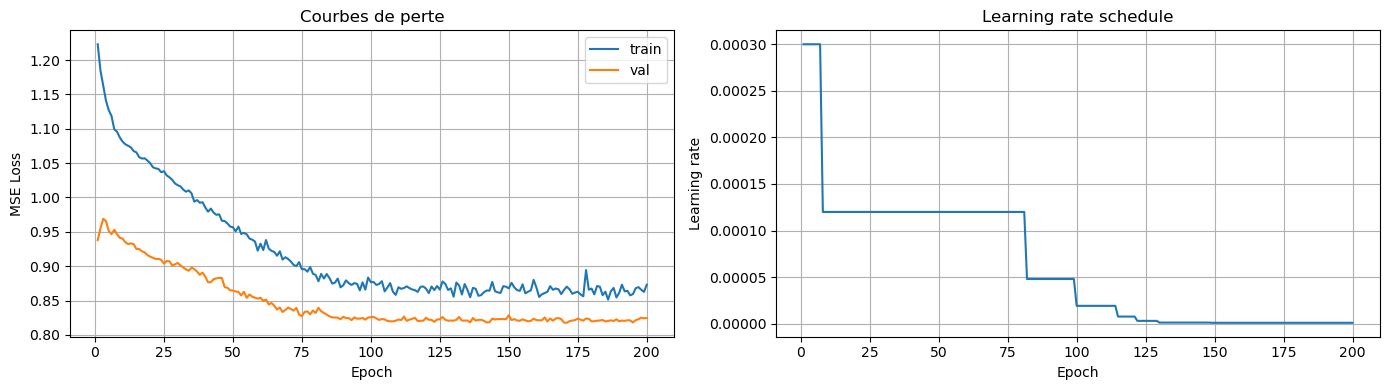

Entraînement terminé en 200 epochs.
Best val_loss = 0.817537


In [103]:
# ============================================================
# Cellule 22 - Courbes d'apprentissage
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_ran, history["train_loss"], label="train")
ax1.plot(epochs_ran, history["val_loss"],   label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Courbes de perte"); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_ran, history["lr"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning rate")
ax2.set_title("Learning rate schedule"); ax2.grid(True)

plt.tight_layout()
plt.show()
print(f"Entraînement terminé en {len(history['train_loss'])} epochs.")
print(f"Best val_loss = {early_stopper.best_loss:.6f}")


In [104]:
# ============================================================
# Cellule - Inverse transform des cibles (corrigée)
# Compatible avec un target_scaler fit sur [T_train, N_GEN]
# ============================================================
import numpy as np

def inverse_transform_targets(arr_scaled: np.ndarray) -> np.ndarray:
    """
    Inverse la normalisation des cibles.
    
    Cas attendu :
    - target_scaler a été fit sur un tableau [T_train, N_GEN]
    - arr_scaled peut être de shape :
        [B, N_GEN, HOR]
        [B, N_GEN]
        [N_GEN]
        [*, N_GEN, *]
    On suppose que l'axe des générateurs = axe 1 si 3D,
    ou dernier axe si 2D simple [B, N_GEN].
    """
    arr = np.asarray(arr_scaled)

    if arr.ndim == 1:
        # [N_GEN]
        return target_scaler.inverse_transform(arr.reshape(1, -1)).reshape(arr.shape)

    elif arr.ndim == 2:
        # [B, N_GEN]
        return target_scaler.inverse_transform(arr)

    elif arr.ndim == 3:
        # Cas typique : [B, N_GEN, HOR]
        # On veut appliquer l'inverse sur l'axe N_GEN
        B, N_GEN_, HOR_ = arr.shape
        arr_2d = arr.transpose(0, 2, 1).reshape(-1, N_GEN_)   # [B*HOR, N_GEN]
        arr_inv = target_scaler.inverse_transform(arr_2d)
        return arr_inv.reshape(B, HOR_, N_GEN_).transpose(0, 2, 1)

    else:
        raise ValueError(f"Shape non supportée pour inverse_transform_targets: {arr.shape}")


# Petit test optionnel
print("target_scaler mean shape :", target_scaler.mean_.shape)
print("target_scaler scale shape:", target_scaler.scale_.shape)

target_scaler mean shape : (15,)
target_scaler scale shape: (15,)


In [105]:
# ============================================================
# Cellule 24 - Baseline persistance (train / val / test)
# ============================================================
def compute_persistence_split(dataset, mode=None):
    mode = mode or CONFIG["PERSISTENCE_MODE"]
    preds, trues = [], []
    for start_idx in dataset.start_indices:
        start_idx   = int(start_idx)
        target_start = start_idx + HIST
        pred = persistence_forecast_for_sample(start_idx, mode=mode)   # [15, HOR]
        true = p_bus_generator[target_start : target_start + HOR].T     # [15, HOR]
        assert pred.shape == (N_GEN, HOR)
        assert true.shape == (N_GEN, HOR)
        preds.append(pred)
        trues.append(true)
    return np.stack(preds, axis=0), np.stack(trues, axis=0)   # [N, 15, HOR]

pers_train_pred, pers_train_true = compute_persistence_split(train_ds)
pers_val_pred,   pers_val_true   = compute_persistence_split(val_ds)
pers_test_pred,  pers_test_true  = compute_persistence_split(test_ds)

print("pers_train_pred.shape =", pers_train_pred.shape)
print("pers_val_pred.shape   =", pers_val_pred.shape)
print("pers_test_pred.shape  =", pers_test_pred.shape)


pers_train_pred.shape = (271, 15, 24)
pers_val_pred.shape   = (31, 15, 24)
pers_test_pred.shape  = (61, 15, 24)


In [106]:
# ============================================================
# Cellule 24bis - Collecte des prédictions
# À exécuter AVANT la cellule 25
# Compatible avec :
# - target_scaler global fit sur reshape(-1,1)
# - target_scaler par générateur fit sur [T_train, N_GEN]
# ============================================================
import numpy as np
import torch

def inverse_targets_flexible(arr_scaled, target_scaler, n_gen, horizon):
    """
    Gère les deux cas :
    1) scaler global         : mean_.shape == (1,) ou scalaire
    2) scaler par générateur : mean_.shape == (n_gen,)
    
    Et les sorties aplaties du notebook :
    - typiquement [B*N_GEN, HOR]
    """
    arr = np.asarray(arr_scaled)
    scaler_shape = np.asarray(target_scaler.mean_).shape

    # --------------------------------------------------------
    # Cas 1 : scaler global
    # --------------------------------------------------------
    if scaler_shape == (1,) or scaler_shape == ():
        return target_scaler.inverse_transform(
            arr.reshape(-1, 1)
        ).reshape(arr.shape)

    # --------------------------------------------------------
    # Cas 2 : scaler par générateur
    # --------------------------------------------------------
    if len(scaler_shape) == 1 and scaler_shape[0] == n_gen:
        if arr.ndim == 2:
            # Cas attendu : [B*N_GEN, HOR]
            assert arr.shape[1] == horizon, \
                f"Horizon inattendu: {arr.shape[1]} vs {horizon}"
            assert arr.shape[0] % n_gen == 0, \
                f"Nb lignes {arr.shape[0]} non divisible par n_gen={n_gen}"

            bsz = arr.shape[0] // n_gen
            arr3 = arr.reshape(bsz, n_gen, horizon)              # [B, N_GEN, HOR]
            arr2 = arr3.transpose(0, 2, 1).reshape(-1, n_gen)    # [B*HOR, N_GEN]
            arr2_inv = target_scaler.inverse_transform(arr2)
            arr3_inv = arr2_inv.reshape(bsz, horizon, n_gen).transpose(0, 2, 1)
            return arr3_inv.reshape(arr.shape)

        elif arr.ndim == 3:
            # [B, N_GEN, HOR]
            assert arr.shape[1] == n_gen and arr.shape[2] == horizon, \
                f"Shape 3D inattendue: {arr.shape}"
            bsz = arr.shape[0]
            arr2 = arr.transpose(0, 2, 1).reshape(-1, n_gen)     # [B*HOR, N_GEN]
            arr2_inv = target_scaler.inverse_transform(arr2)
            return arr2_inv.reshape(bsz, horizon, n_gen).transpose(0, 2, 1)

        else:
            raise ValueError(f"ndim non supporté pour inverse cible: {arr.ndim}")

    raise ValueError(
        f"target_scaler incompatible : mean_.shape={scaler_shape}, attendu (1,) ou ({n_gen},)"
    )

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()

    preds_scaled = []
    trues_scaled = []
    preds_real   = []
    trues_real   = []
    metas        = []

    for batch in loader:
        batch = batch.to(DEVICE)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.generator_mask
        )

        y_true = batch.y

        pred_np = pred.detach().cpu().numpy()
        true_np = y_true.detach().cpu().numpy()

        preds_scaled.append(pred_np)
        trues_scaled.append(true_np)

        preds_real.append(
            inverse_targets_flexible(pred_np, target_scaler, N_GEN, HOR)
        )
        trues_real.append(
            inverse_targets_flexible(true_np, target_scaler, N_GEN, HOR)
        )

        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)
    preds_real   = np.concatenate(preds_real, axis=0)
    trues_real   = np.concatenate(trues_real, axis=0)

    if len(metas) > 0:
        metas = np.concatenate(metas, axis=0)
    else:
        metas = np.array([])

    print("\n--- collect_predictions ---")
    print("target_scaler mean_.shape =", np.asarray(target_scaler.mean_).shape)
    print("preds_scaled.shape        =", preds_scaled.shape)
    print("trues_scaled.shape        =", trues_scaled.shape)
    print("preds_real.shape          =", preds_real.shape)
    print("trues_real.shape          =", trues_real.shape)
    print("metas.shape               =", metas.shape)

    return {
        "preds_scaled": preds_scaled,
        "trues_scaled": trues_scaled,
        "preds_real": preds_real,
        "trues_real": trues_real,
        "metas": metas,
    }

train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)


--- collect_predictions ---
target_scaler mean_.shape = (15,)
preds_scaled.shape        = (4065, 24)
trues_scaled.shape        = (4065, 24)
preds_real.shape          = (4065, 24)
trues_real.shape          = (4065, 24)
metas.shape               = (271,)

--- collect_predictions ---
target_scaler mean_.shape = (15,)
preds_scaled.shape        = (465, 24)
trues_scaled.shape        = (465, 24)
preds_real.shape          = (465, 24)
trues_real.shape          = (465, 24)
metas.shape               = (31,)

--- collect_predictions ---
target_scaler mean_.shape = (15,)
preds_scaled.shape        = (915, 24)
trues_scaled.shape        = (915, 24)
preds_real.shape          = (915, 24)
trues_real.shape          = (915, 24)
metas.shape               = (61,)


In [107]:
# ============================================================
# Cellule 25 - Métriques (par split, par bus générateur, global)
# ============================================================
import numpy as np
import pandas as pd

def ensure_3d_output(arr, n_gen, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_gen and arr.shape[2] == horizon, \
            f"Shape 3D inattendue: {arr.shape}, attendu (*, {n_gen}, {horizon})"
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon, \
            f"Shape 2D inattendue: {arr.shape}, horizon attendu={horizon}"
        assert arr.shape[0] % n_gen == 0, \
            f"Lignes {arr.shape[0]} non divisible par n_gen={n_gen}"
        return arr.reshape(arr.shape[0] // n_gen, n_gen, horizon)
    raise ValueError(f"ndim non supporté: {arr.ndim}")

def evaluate_output_dict(out, split_name):
    preds_3d = ensure_3d_output(out["preds_real"], N_GEN, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_GEN, HOR)

    rows = []

    # Global
    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({
        "split": split_name,
        "model": "SpatialElecGNN_global"
    })
    rows.append(m)

    # Par bus générateur
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"SpatialElecGNN_bus_{bus_idx}",
            "bus_global_idx": bus_idx,
            "bus_name": buses_df.iloc[bus_idx]["Name"]
        })
        rows.append(m)

    return pd.DataFrame(rows)

def evaluate_baseline(pred, true, split_name):
    pred_3d = ensure_3d_output(pred, N_GEN, HOR)
    true_3d = ensure_3d_output(true, N_GEN, HOR)

    rows = []

    # Global
    m = mae_rmse_nmae(true_3d, pred_3d)
    m.update({
        "split": split_name,
        "model": "Persistence_global"
    })
    rows.append(m)

    # Par bus générateur
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(true_3d[:, j, :], pred_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"Persistence_bus_{bus_idx}",
            "bus_global_idx": bus_idx,
            "bus_name": buses_df.iloc[bus_idx]["Name"]
        })
        rows.append(m)

    return pd.DataFrame(rows)

metrics_df = pd.concat([
    evaluate_output_dict(train_out, "train"),
    evaluate_output_dict(val_out,   "val"),
    evaluate_output_dict(test_out,  "test"),
    evaluate_baseline(pers_train_pred, pers_train_true, "train"),
    evaluate_baseline(pers_val_pred,   pers_val_true,   "val"),
    evaluate_baseline(pers_test_pred,  pers_test_true,  "test"),
], axis=0, ignore_index=True)

display(metrics_df)

print("\nRésumé test (global) :")
display(
    metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"].str.contains("global"))
    ]
)

,MAE,RMSE,NMAE,split,model,bus_global_idx,bus_name
0,1.267300,2.044307,0.334572,train,SpatialElecGNN_global,NaN,NaN
1,0.065670,0.108836,1.624952,train,SpatialElecGNN_bus_6,6.0,BRUEG
2,2.192844,3.007370,0.123480,train,SpatialElecGNN_bus_12,12.0,DOEL
3,1.005411,1.547530,1.610792,train,SpatialElecGNN_bus_14,14.0,GEZEL
4,4.296441,4.766248,0.580998,train,SpatialElecGNN_bus_15,15.0,GOUY
...,...,...,...,...,...,...,...
91,0.269098,0.502018,0.705823,test,Persistence_bus_37,37.0,STAM+
92,0.551109,2.037342,0.036623,test,Persistence_bus_39,39.0,TIHA1
93,0.943515,1.671871,0.441155,test,Persistence_bus_41,41.0,VERBR
94,0.475874,1.299781,0.125538,test,Persistence_bus_43,43.0,ZANDV



Résumé test (global) :


,MAE,RMSE,NMAE,split,model,bus_global_idx,bus_name
32,1.883560,2.843570,0.434344,test,SpatialElecGNN_global,NaN,NaN
80,0.854158,2.029165,0.196967,test,Persistence_global,NaN,NaN


In [108]:
# ============================================================
# Cellule 26 - Diagnostic d'alignement
# ============================================================
def diagnose_alignment(out, n_checks=5):
    assert out["metas"] is not None, "metas est None"
    preds_3d = ensure_3d_output(out["preds_real"], N_GEN, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_GEN, HOR)
    metas = np.asarray(out["metas"]).reshape(-1)
    n = min(n_checks, len(metas), len(trues_3d))
    for k in range(n):
        ts0 = int(metas[k])
        expected = p_bus_generator[ts0 : ts0 + HOR].T   # [15, HOR]
        actual   = trues_3d[k]
        assert expected.shape == actual.shape
        assert np.allclose(expected, actual, atol=1e-6), f"Erreur alignement k={k}"
        print(f"k={k} | target_start={ts0} | {ts_p[ts0]} → {ts_p[ts0+HOR-1]} | OK")

diagnose_alignment(test_out, n_checks=CONFIG["NUM_ALIGNMENT_CHECKS"])
print("Diagnostic d'alignement test OK.")


k=0 | target_start=7320 | 2024-11-01 00:00:00 → 2024-11-01 23:00:00 | OK
k=1 | target_start=7344 | 2024-11-02 00:00:00 → 2024-11-02 23:00:00 | OK
k=2 | target_start=7368 | 2024-11-03 00:00:00 → 2024-11-03 23:00:00 | OK
k=3 | target_start=7392 | 2024-11-04 00:00:00 → 2024-11-04 23:00:00 | OK
k=4 | target_start=7416 | 2024-11-05 00:00:00 → 2024-11-05 23:00:00 | OK
Diagnostic d'alignement test OK.


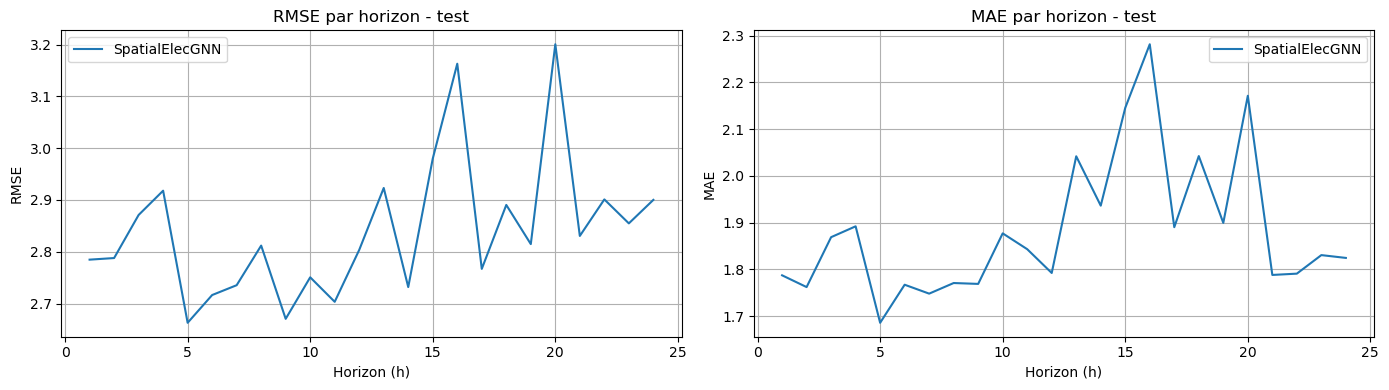

,h,MAE,RMSE,NMAE
0,1,1.787223,2.784723,0.442025
1,2,1.762033,2.787817,0.468620
2,3,1.868850,2.870957,0.520468
3,4,1.892066,2.917839,0.539532
4,5,1.685605,2.662818,0.481311


In [109]:
# ============================================================
# Cellule 27 - Métriques par horizon
# ============================================================
assert "test_out" in globals()
assert "pers_test_true" in globals()
assert "pers_test_pred" in globals()

def per_horizon_metrics(y_true, y_pred):
    y_true_3d = ensure_3d_output(y_true, N_GEN, HOR)
    y_pred_3d = ensure_3d_output(y_pred, N_GEN, HOR)
    rows = []
    for h in range(HOR):
        m = mae_rmse_nmae(y_true_3d[:, :, h], y_pred_3d[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

test_horizon_df      = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])
pers_test_horizon_df = per_horizon_metrics(pers_test_true, pers_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(test_horizon_df["h"],      test_horizon_df["RMSE"],      label="SpatialElecGNN")
ax1.set(xlabel="Horizon (h)", ylabel="RMSE", title="RMSE par horizon - test")
ax1.legend(); ax1.grid(True)

ax2.plot(test_horizon_df["h"],      test_horizon_df["MAE"],      label="SpatialElecGNN")
ax2.set(xlabel="Horizon (h)", ylabel="MAE", title="MAE par horizon - test")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()
display(test_horizon_df.head())


In [110]:
# ============================================================
# Cellule 28 - Reconstruction continue test (true_cont / pred_cont)
# ============================================================
N_GEN_CONT = N_GEN
true_cont = np.full((T, N_GEN_CONT), np.nan)
pred_cont = np.full((T, N_GEN_CONT), np.nan)

preds_3d = ensure_3d_output(test_out["preds_real"], N_GEN, HOR)
metas    = test_out["metas"]

assert metas is not None
assert len(metas) == len(preds_3d), \
    f"Incohérence : {len(metas)} metas vs {len(preds_3d)} fenêtres"

for k, ts0 in enumerate(metas):
    ts0 = int(ts0)
    for j in range(N_GEN_CONT):
        true_cont[ts0 : ts0 + HOR, j] = p_bus_generator[ts0 : ts0 + HOR, j]
        pred_cont[ts0 : ts0 + HOR, j] = preds_3d[k, j, :]

n_valid = int(np.sum(np.any(~np.isnan(true_cont), axis=1)))
print(f"Reconstruction continue : {n_valid} heures valides sur {T}")
print(f"true_cont.shape = {true_cont.shape}")
print(f"pred_cont.shape = {pred_cont.shape}")


Reconstruction continue : 1464 heures valides sur 8784
true_cont.shape = (8784, 15)
pred_cont.shape = (8784, 15)


Zoom 72h de 2024-11-01 00:00:00 à 2024-11-03 23:00:00


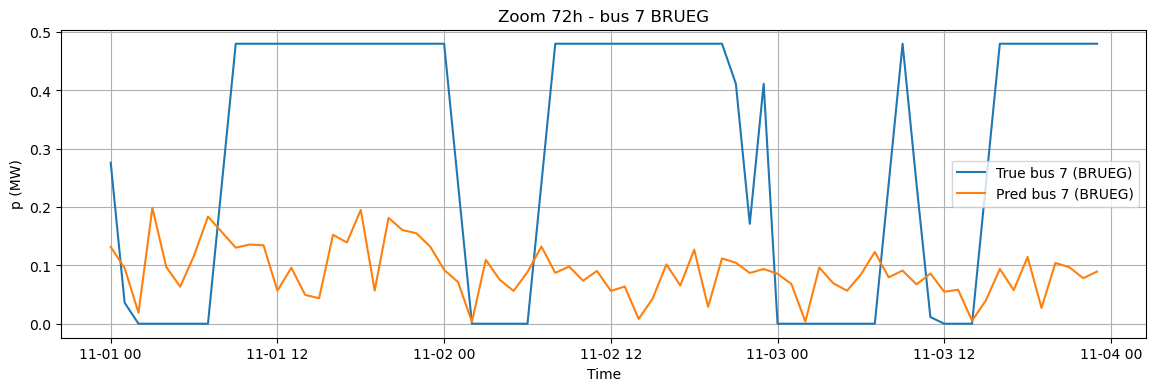

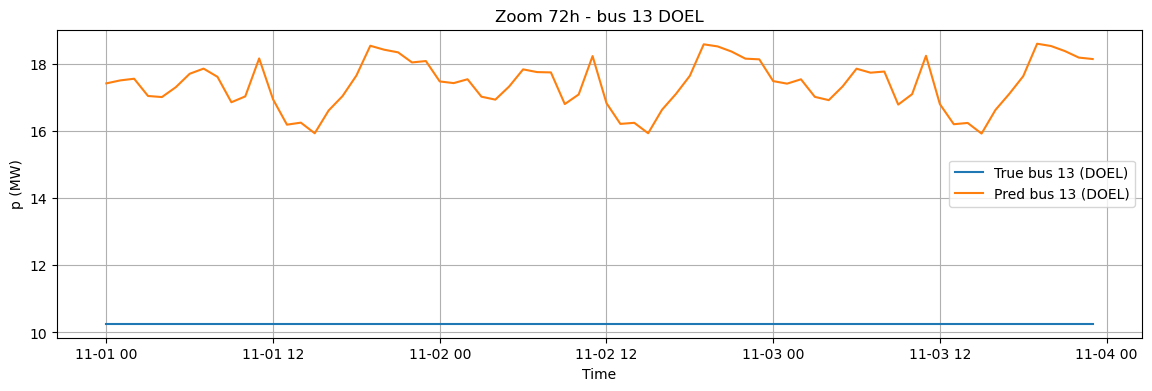

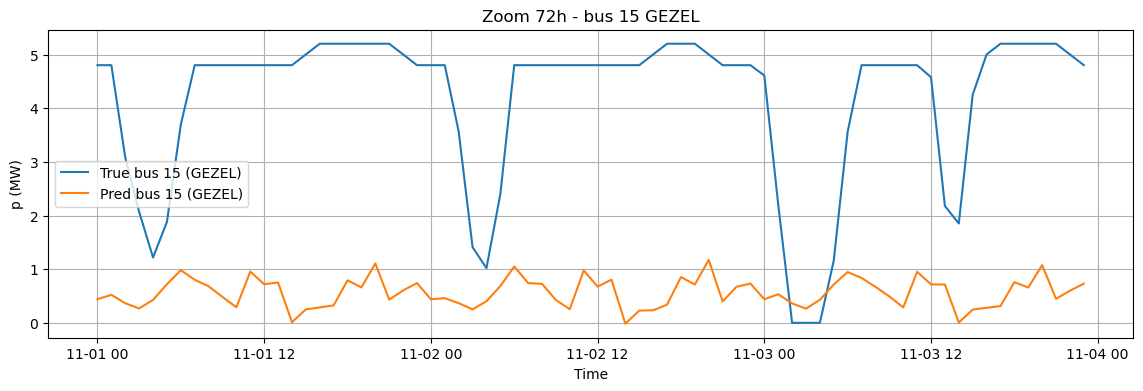

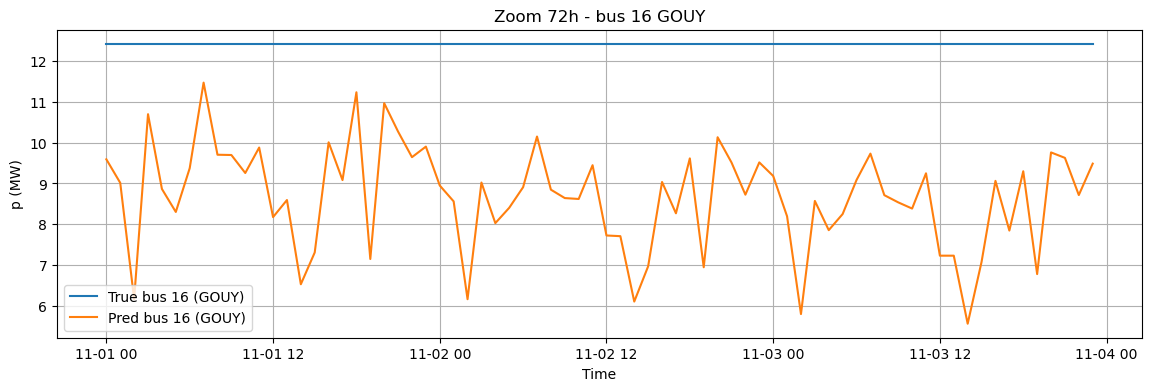

In [111]:
# ============================================================
# Cellule 29 - Zoom 72h sur les bus générateurs (top 4)
# ============================================================
N_ZOOM = 72
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx        = np.where(valid_hours_mask)[0]
assert len(valid_idx) > 0, "Aucune heure valide"

start_plot = valid_idx[0]
end_plot   = min(start_plot + N_ZOOM, T)
print("Zoom 72h de", ts_p[start_plot], "à", ts_p[end_plot - 1])

# Afficher les 4 premiers bus générateurs
for j in range(min(4, N_GEN)):
    bus_idx = CONFIG["GENERATOR_BUS_IDX"][j]
    bus_name = buses_df.iloc[bus_idx]["Name"]
    plt.figure(figsize=(14, 4))
    plt.plot(ts_p[start_plot:end_plot], true_cont[start_plot:end_plot, j],
             label=f"True bus {bus_idx+1} ({bus_name})")
    plt.plot(ts_p[start_plot:end_plot], pred_cont[start_plot:end_plot, j],
             label=f"Pred bus {bus_idx+1} ({bus_name})")
    plt.title(f"Zoom 72h - bus {bus_idx+1} {bus_name}")
    plt.xlabel("Time"); plt.ylabel("p (MW)"); plt.grid(True); plt.legend()
    plt.show()


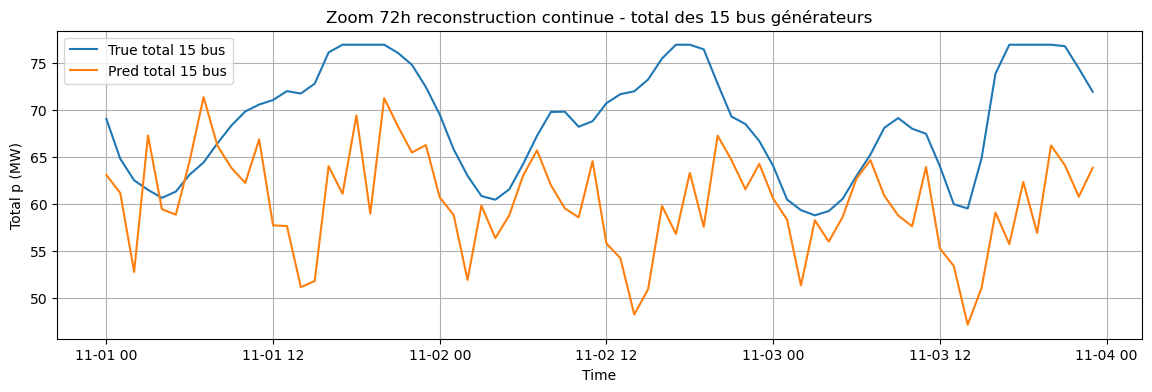

In [112]:
# ============================================================
# Cellule 30 - Zoom 72h sur le total des 15 bus générateurs
# ============================================================
N_ZOOM = 72
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx        = np.where(valid_hours_mask)[0]
start_plot = valid_idx[0]
end_plot   = min(start_plot + N_ZOOM, T)

true_total_72h = np.nansum(true_cont[start_plot:end_plot, :], axis=1)
pred_total_72h = np.nansum(pred_cont[start_plot:end_plot, :], axis=1)

plt.figure(figsize=(14, 4))
plt.plot(ts_p[start_plot:end_plot], true_total_72h, label="True total 15 bus")
plt.plot(ts_p[start_plot:end_plot], pred_total_72h, label="Pred total 15 bus")
plt.title("Zoom 72h reconstruction continue - total des 15 bus générateurs")
plt.xlabel("Time"); plt.ylabel("Total p (MW)"); plt.grid(True); plt.legend()
plt.show()


In [113]:
# ============================================================
# Cellule 31 - Métriques sur les totaux agrégés (15 bus)
# ============================================================
def aggregated_total_metrics(true_arr, pred_arr, n_gen, horizon):
    true_3d = ensure_3d_output(true_arr, n_gen, horizon)
    pred_3d = ensure_3d_output(pred_arr, n_gen, horizon)
    assert true_3d.shape == pred_3d.shape

    true_total = np.sum(true_3d, axis=1)   # [N, HOR]
    pred_total = np.sum(pred_3d, axis=1)
    err_total  = pred_total - true_total

    mae_total  = np.mean(np.abs(err_total))
    rmse_total = np.sqrt(np.mean(err_total ** 2))
    std_err    = np.std(err_total)
    mean_abs   = np.mean(np.abs(true_total))
    nmae_total = mae_total / (mean_abs + 1e-12)

    metrics = {
        "MAE_total_agg" : mae_total,
        "RMSE_total_agg": rmse_total,
        "STD_error_agg" : std_err,
        "mean_abs_true" : mean_abs,
        "NMAE_total_agg": nmae_total,
    }
    return metrics, true_total, pred_total, err_total

gnn_metrics,  gnn_true_tot,  gnn_pred_tot,  _ = aggregated_total_metrics(
    test_out["trues_real"], test_out["preds_real"], N_GEN, HOR)
pers_metrics, pers_true_tot, pers_pred_tot, _ = aggregated_total_metrics(
    pers_test_true, pers_test_pred, N_GEN, HOR)

df_total_metrics = pd.DataFrame([
    {"model": "SpatialElecGNN", **gnn_metrics},
    {"model": "Persistence",    **pers_metrics},
])
display(df_total_metrics)

print("\n--- Détail SpatialElecGNN ---")
for k, v in gnn_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n--- Détail Persistence ---")
for k, v in pers_metrics.items():
    print(f"{k}: {v:.4f}")


,model,MAE_total_agg,RMSE_total_agg,STD_error_agg,mean_abs_true,NMAE_total_agg
0,SpatialElecGNN,12.508652,15.309381,15.226587,65.048431,0.192298
1,Persistence,11.416090,15.119200,15.112613,65.048435,0.175501



--- Détail SpatialElecGNN ---
MAE_total_agg: 12.5087
RMSE_total_agg: 15.3094
STD_error_agg: 15.2266
mean_abs_true: 65.0484
NMAE_total_agg: 0.1923

--- Détail Persistence ---
MAE_total_agg: 11.4161
RMSE_total_agg: 15.1192
STD_error_agg: 15.1126
mean_abs_true: 65.0484
NMAE_total_agg: 0.1755


=== SpatialElecGNN | Global metrics on validation (total des 15 bus générateurs) ===
MAE            : 12.847018
RMSE           : 15.937345
MAE/mean       : 0.203948
Roughness err  : 0.575006
Roughness true : 4.573113
Roughness pred : 3.998108


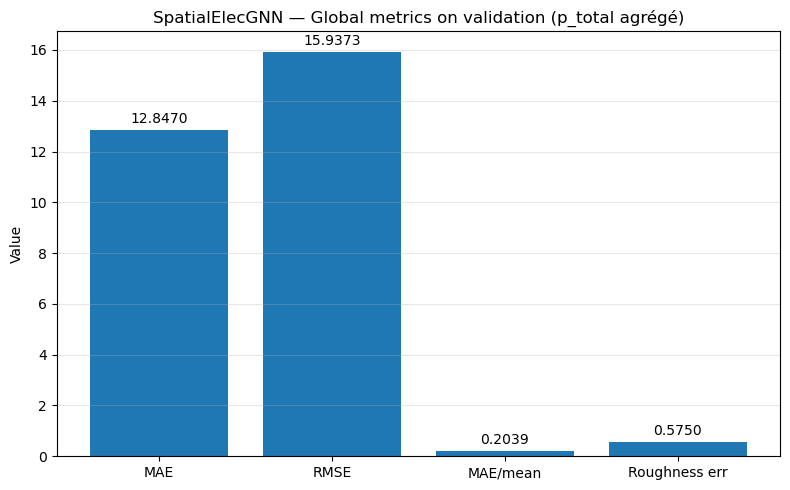

Figure saved to: C:\Users\yoans\TFE - GAZ\figures\global_metrics_val_spatial_elec_gnn.png


In [114]:
# ============================================================
# Cellule — Global metrics plot | VAL | SpatialElecGNN
# Adaptée au notebook "GNN spatial elec"
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# Vérifications minimales
# ------------------------------------------------------------
assert "val_out" in globals(), "val_out introuvable. Exécute d'abord la cellule 23."
assert "ensure_3d_output" in globals(), "ensure_3d_output introuvable. Exécute d'abord la cellule 25."
assert "N_GEN" in globals(), "N_GEN introuvable."
assert "HOR" in globals(), "HOR introuvable."

# ------------------------------------------------------------
# Prédictions globales sur le set de validation
# val_out['preds_real'] et val_out['trues_real'] ont typiquement
# une shape [N_windows * N_GEN, HOR]
# ------------------------------------------------------------
pred_real_3d = ensure_3d_output(val_out["preds_real"], N_GEN, HOR)   # [N, N_GEN, HOR]
true_real_3d = ensure_3d_output(val_out["trues_real"], N_GEN, HOR)   # [N, N_GEN, HOR]

# ------------------------------------------------------------
# Total élec agrégé sur les 15 bus générateurs
# Somme sur les générateurs -> [N, HOR], puis flatten
# ------------------------------------------------------------
p_pred_total = pred_real_3d.sum(axis=1).reshape(-1)
p_true_total = true_real_3d.sum(axis=1).reshape(-1)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metric_mae       = mae(p_true_total, p_pred_total)
metric_rmse      = rmse(p_true_total, p_pred_total)
metric_mae_mean  = metric_mae / (np.mean(np.abs(p_true_total)) + 1e-12)
rough_true       = roughness(p_true_total)
rough_pred       = roughness(p_pred_total)
metric_roughness = abs(rough_pred - rough_true)

metrics = {
    "MAE": metric_mae,
    "RMSE": metric_rmse,
    "MAE/mean": metric_mae_mean,
    "Roughness err": metric_roughness
}

print("=== SpatialElecGNN | Global metrics on validation (total des 15 bus générateurs) ===")
for k, v in metrics.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
names  = list(metrics.keys())
values = list(metrics.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)

ax.set_title("SpatialElecGNN — Global metrics on validation (p_total agrégé)")
ax.set_ylabel("Value")
ax.grid(True, axis="y", alpha=0.3)

ymax = max(values) if len(values) > 0 else 1.0
for b, v in zip(bars, values):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.01 * ymax,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.tight_layout()

# ------------------------------------------------------------
# Sauvegarde
# ------------------------------------------------------------
save_dir = CONFIG["BASE_DIR"] / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "global_metrics_val_spatial_elec_gnn.png"
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path.resolve())

=== STD ANALYSIS | SpatialElecGNN | Validation ===
STD globale true                : 6.557260
STD globale pred                : 5.906697
Ratio pred/true globale         : 0.900787
-
STD totale agrégée true         : 16.342678
STD totale agrégée pred         : 6.152905
Ratio pred/true totale agrégée  : 0.376493

Générateurs les plus sous-variés (pred - true le plus négatif):
Gen 03 | std_true=5.0907 | std_pred=1.8534 | diff=-3.2373
Gen 02 | std_true=1.7701 | std_pred=0.2809 | diff=-1.4892
Gen 09 | std_true=1.9715 | std_pred=0.5634 | diff=-1.4082
Gen 06 | std_true=1.9687 | std_pred=0.5754 | diff=-1.3933
Gen 08 | std_true=2.1078 | std_pred=0.8857 | diff=-1.2222

Générateurs les plus sur-variés (pred - true le plus positif):
Gen 04 | std_true=0.0127 | std_pred=0.0029 | diff=-0.0097
Gen 00 | std_true=0.1216 | std_pred=0.0488 | diff=-0.0728
Gen 14 | std_true=0.1042 | std_pred=0.0295 | diff=-0.0747
Gen 10 | std_true=0.2587 | std_pred=0.1251 | diff=-0.1336
Gen 01 | std_true=1.0234 | std_pred=0

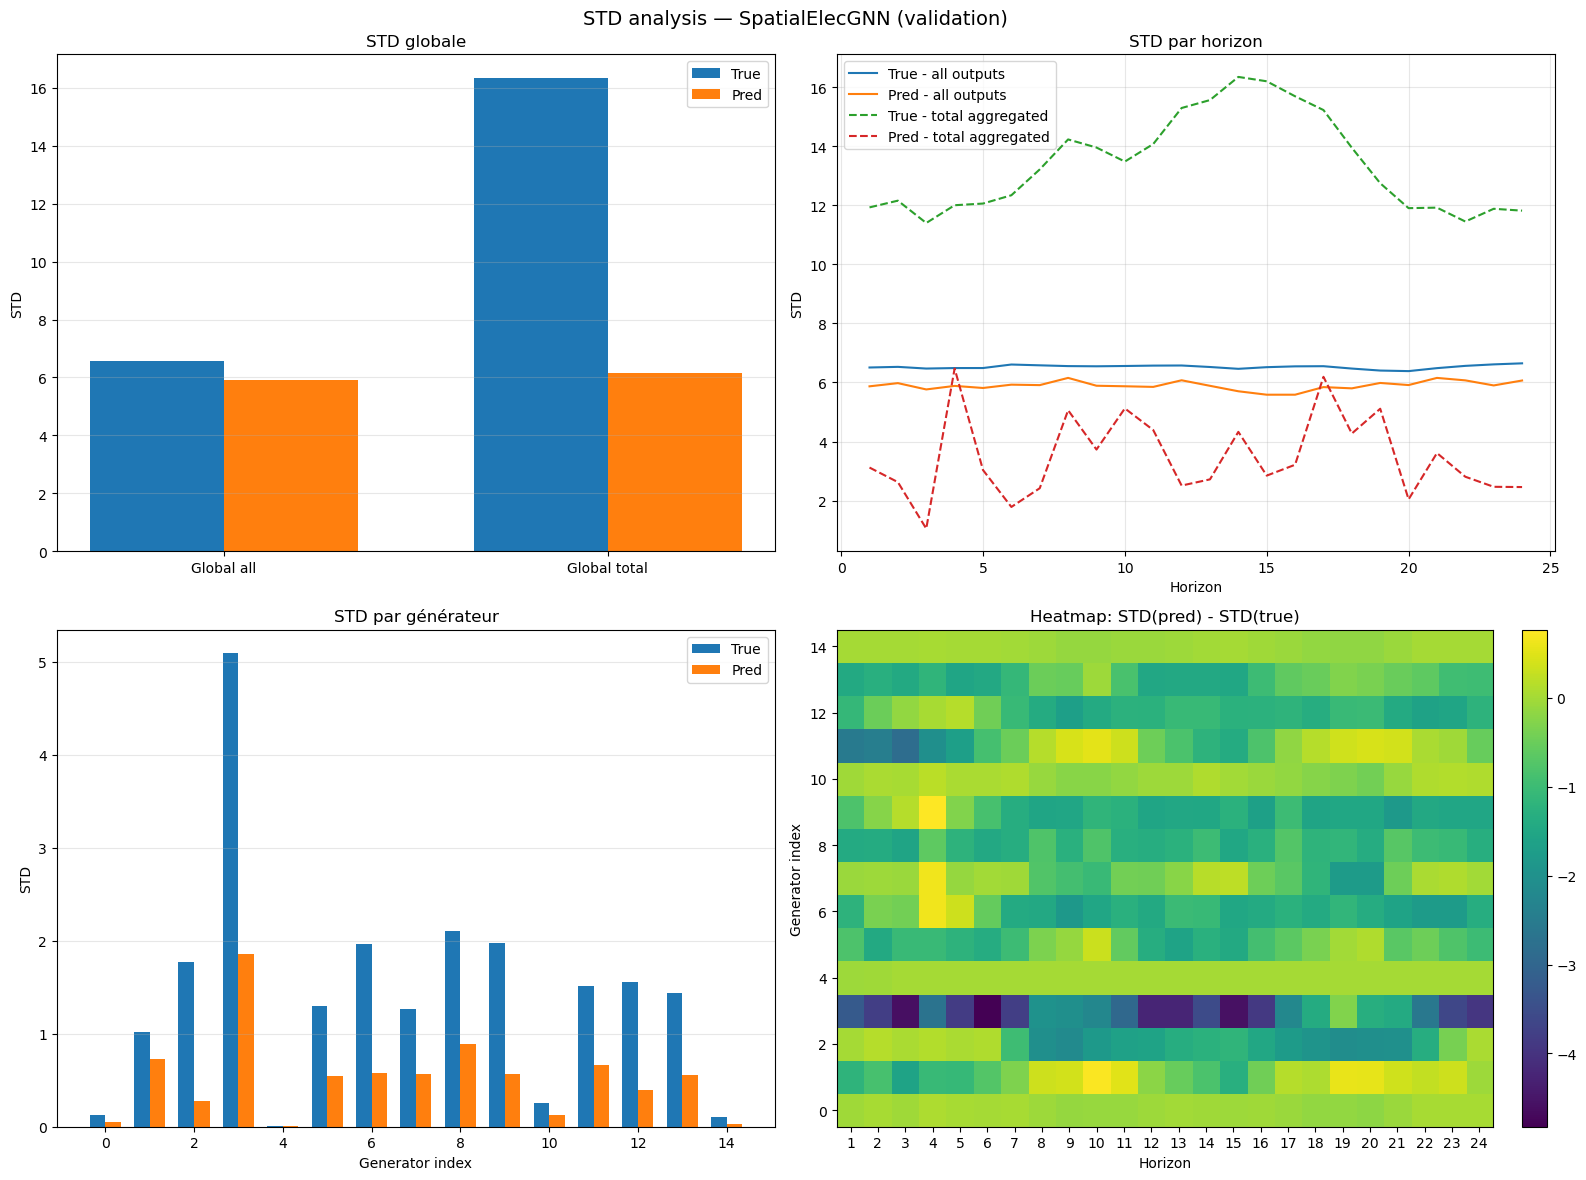

In [115]:
# ============================================================
# Cellule — STD analysis | VAL | SpatialElecGNN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
assert "val_out" in globals(), "val_out introuvable."
assert "ensure_3d_output" in globals(), "ensure_3d_output introuvable."
assert "N_GEN" in globals(), "N_GEN introuvable."
assert "HOR" in globals(), "HOR introuvable."

# ------------------------------------------------------------
# Mise en forme [N, N_GEN, HOR]
# ------------------------------------------------------------
pred_3d = ensure_3d_output(val_out["preds_real"], N_GEN, HOR)
true_3d = ensure_3d_output(val_out["trues_real"], N_GEN, HOR)

# Convention pour l'analyse:
# pred_3d / true_3d: [N_windows, N_GEN, HOR]

# ------------------------------------------------------------
# 1) STD globale sur toutes les valeurs
# ------------------------------------------------------------
std_true_global = float(np.std(true_3d))
std_pred_global = float(np.std(pred_3d))

# ------------------------------------------------------------
# 2) STD du total agrégé par fenêtre/horizon
# ------------------------------------------------------------
true_total = true_3d.sum(axis=1)   # [N, HOR]
pred_total = pred_3d.sum(axis=1)   # [N, HOR]

std_true_total_global = float(np.std(true_total))
std_pred_total_global = float(np.std(pred_total))

# ------------------------------------------------------------
# 3) STD par horizon
# ------------------------------------------------------------
# sur signal complet (tous les générateurs)
std_true_h = np.std(true_3d, axis=(0, 1))   # [HOR]
std_pred_h = np.std(pred_3d, axis=(0, 1))   # [HOR]

# sur total agrégé
std_true_total_h = np.std(true_total, axis=0)   # [HOR]
std_pred_total_h = np.std(pred_total, axis=0)   # [HOR]

# ------------------------------------------------------------
# 4) STD par générateur
# ------------------------------------------------------------
std_true_gen = np.std(true_3d, axis=(0, 2))   # [N_GEN]
std_pred_gen = np.std(pred_3d, axis=(0, 2))   # [N_GEN]

# ------------------------------------------------------------
# 5) Heatmap écart de STD par (générateur, horizon)
# ------------------------------------------------------------
std_true_gen_h = np.std(true_3d, axis=0)   # [N_GEN, HOR]
std_pred_gen_h = np.std(pred_3d, axis=0)   # [N_GEN, HOR]
std_diff_gen_h = std_pred_gen_h - std_true_gen_h

# ------------------------------------------------------------
# Résumé texte
# ------------------------------------------------------------
print("=== STD ANALYSIS | SpatialElecGNN | Validation ===")
print(f"STD globale true                : {std_true_global:.6f}")
print(f"STD globale pred                : {std_pred_global:.6f}")
print(f"Ratio pred/true globale         : {std_pred_global / (std_true_global + 1e-12):.6f}")
print("-")
print(f"STD totale agrégée true         : {std_true_total_global:.6f}")
print(f"STD totale agrégée pred         : {std_pred_total_global:.6f}")
print(f"Ratio pred/true totale agrégée  : {std_pred_total_global / (std_true_total_global + 1e-12):.6f}")

# générateurs les plus sous-lissés / sur-variés
gen_diff = std_pred_gen - std_true_gen
most_under = np.argsort(gen_diff)[:5]
most_over  = np.argsort(gen_diff)[-5:]

print("\nGénérateurs les plus sous-variés (pred - true le plus négatif):")
for idx in most_under:
    print(
        f"Gen {idx:02d} | std_true={std_true_gen[idx]:.4f} | "
        f"std_pred={std_pred_gen[idx]:.4f} | diff={gen_diff[idx]:.4f}"
    )

print("\nGénérateurs les plus sur-variés (pred - true le plus positif):")
for idx in most_over[::-1]:
    print(
        f"Gen {idx:02d} | std_true={std_true_gen[idx]:.4f} | "
        f"std_pred={std_pred_gen[idx]:.4f} | diff={gen_diff[idx]:.4f}"
    )

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))

# --- Plot 1: barplot STD globales
ax1 = plt.subplot(2, 2, 1)
labels = ["Global all", "Global total"]
true_vals = [std_true_global, std_true_total_global]
pred_vals = [std_pred_global, std_pred_total_global]

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, true_vals, width=w, label="True")
ax1.bar(x + w/2, pred_vals, width=w, label="Pred")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("STD globale")
ax1.set_ylabel("STD")
ax1.grid(True, axis="y", alpha=0.3)
ax1.legend()

# --- Plot 2: STD par horizon
ax2 = plt.subplot(2, 2, 2)
h = np.arange(1, HOR + 1)
ax2.plot(h, std_true_h, label="True - all outputs")
ax2.plot(h, std_pred_h, label="Pred - all outputs")
ax2.plot(h, std_true_total_h, linestyle="--", label="True - total aggregated")
ax2.plot(h, std_pred_total_h, linestyle="--", label="Pred - total aggregated")
ax2.set_title("STD par horizon")
ax2.set_xlabel("Horizon")
ax2.set_ylabel("STD")
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Plot 3: STD par générateur
ax3 = plt.subplot(2, 2, 3)
g = np.arange(N_GEN)
ax3.bar(g - w/2, std_true_gen, width=w, label="True")
ax3.bar(g + w/2, std_pred_gen, width=w, label="Pred")
ax3.set_title("STD par générateur")
ax3.set_xlabel("Generator index")
ax3.set_ylabel("STD")
ax3.grid(True, axis="y", alpha=0.3)
ax3.legend()

# --- Plot 4: heatmap diff STD
ax4 = plt.subplot(2, 2, 4)
im = ax4.imshow(std_diff_gen_h, aspect="auto", origin="lower")
ax4.set_title("Heatmap: STD(pred) - STD(true)")
ax4.set_xlabel("Horizon")
ax4.set_ylabel("Generator index")
ax4.set_xticks(np.arange(HOR))
ax4.set_xticklabels(np.arange(1, HOR + 1))
fig.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

fig.suptitle("STD analysis — SpatialElecGNN (validation)", fontsize=14)
fig.tight_layout()
plt.show()

ts_.shape        = (8784,)
dyn_tensor_.shape = (8784, 45, 3)

Résumé statistique :


,feat_0,feat_1,feat_2
count,395280.000000,395280.000000,395280.000000
mean,152.119565,17.889634,17.889634
std,166.113646,162.495769,33.099515
min,0.000000,-7.980000,-0.825963
25%,0.000000,0.000000,0.000000
50%,95.407121,0.000000,3.278710
75%,247.643344,0.000000,17.437125
max,837.813792,2149.152500,222.446182


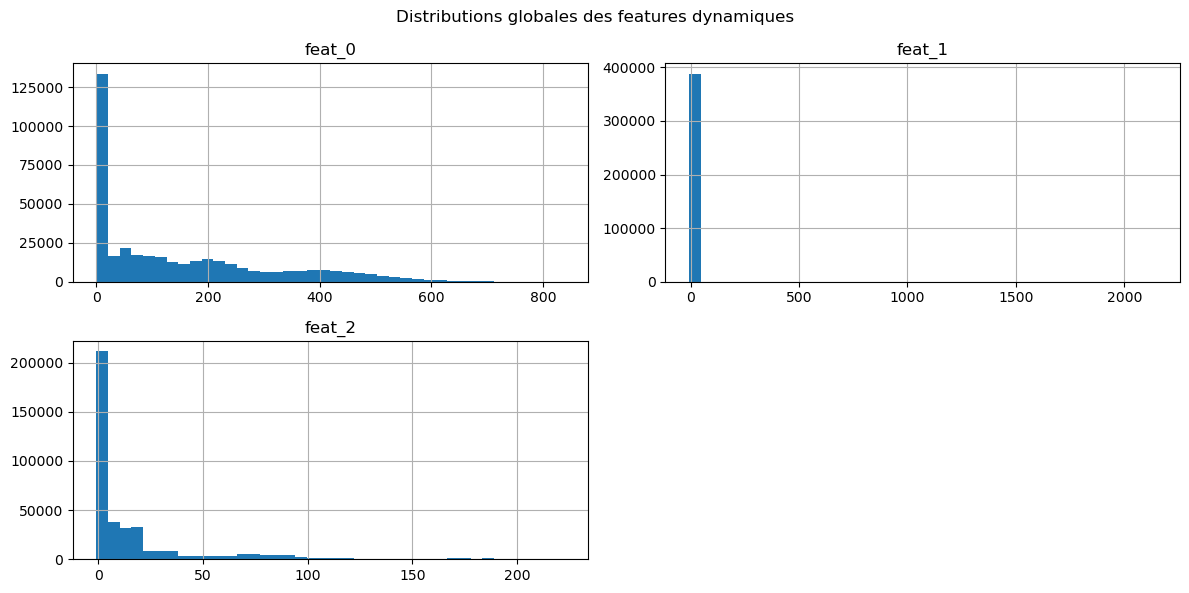

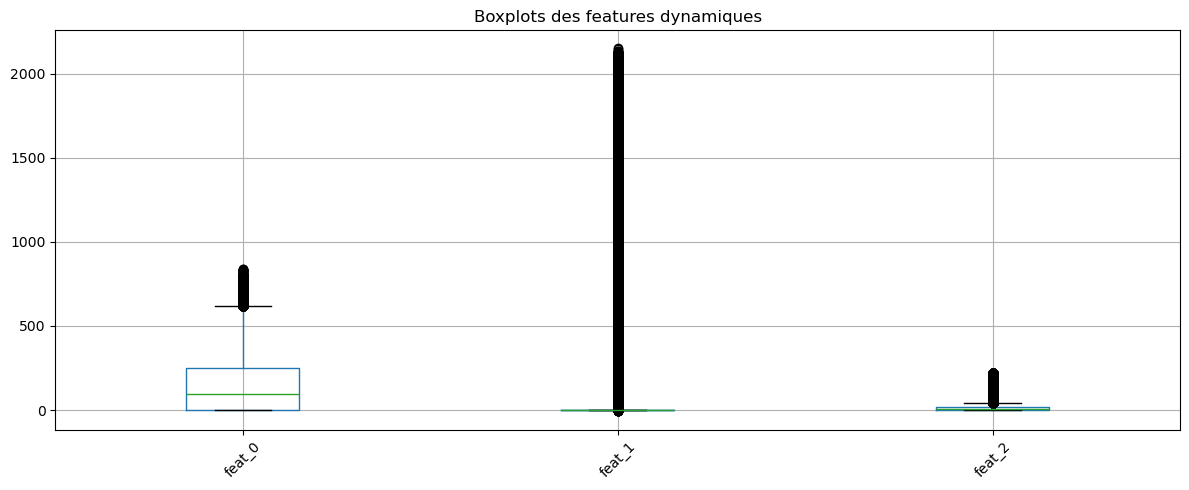

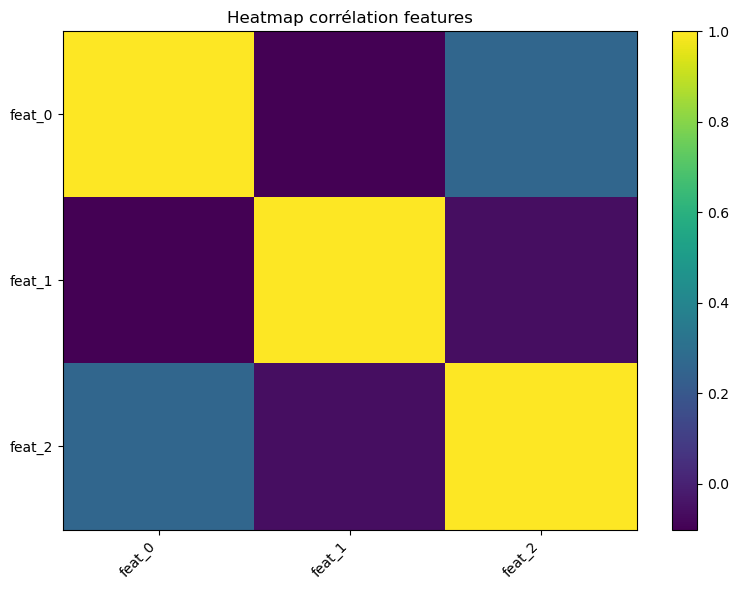

In [116]:
# ============================================================
# Cellule D3 - Distributions globales + boxplots + heatmap corr
# Sert à voir bruit, asymétrie, outliers, variables peu informatives
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Récupération robuste des variables attendues
# ------------------------------------------------------------
if "ts_" not in globals():
    if "ts_p" in globals():
        ts_ = pd.to_datetime(ts_p)
    else:
        raise NameError("Variable ts_ absente. Exécuter d'abord D1 ou définir ts_ / ts_p.")

if "dyn_tensor_" not in globals():
    if "dyn_tensor" in globals():
        dyn_tensor_ = dyn_tensor
    elif "dyn_tensor_scaled" in globals():
        dyn_tensor_ = dyn_tensor_scaled
    else:
        raise NameError("Variable dyn_tensor_ absente. Exécuter d'abord D1 ou définir dyn_tensor_.")

print("ts_.shape        =", np.asarray(ts_).shape)
print("dyn_tensor_.shape =", np.asarray(dyn_tensor_).shape)

# ---------- sous-ensemble lisible ----------
n_feat_show = min(6, dyn_tensor_.shape[-1])

# Exemple simple : moyenne temporelle par feature
flat = dyn_tensor_.reshape(-1, dyn_tensor_.shape[-1])
df_feat = pd.DataFrame(flat[:, :n_feat_show], columns=[f"feat_{i}" for i in range(n_feat_show)])

print("\nRésumé statistique :")
display(df_feat.describe())

# ---------- histogrammes ----------
df_feat.hist(figsize=(12, 6), bins=40)
plt.suptitle("Distributions globales des features dynamiques")
plt.tight_layout()
plt.show()

# ---------- boxplots ----------
plt.figure(figsize=(12, 5))
df_feat.boxplot(rot=45)
plt.title("Boxplots des features dynamiques")
plt.tight_layout()
plt.show()

# ---------- heatmap corr ----------
corr = df_feat.corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Heatmap corrélation features")
plt.tight_layout()
plt.show()

,horizon,GNN_MAE,GNN_RMSE,PERS_MAE,PERS_RMSE
0,1,1.948024,2.951188,0.865790,2.056739
1,2,1.904474,2.906683,0.880724,2.077306
2,3,1.851070,2.849244,0.891545,2.104289
3,4,1.841873,2.852827,0.868518,2.159670
4,5,1.796015,2.778636,0.847589,2.124881
5,6,1.809224,2.824585,0.871781,2.046383
6,7,1.848544,2.895575,0.888423,2.043947
7,8,1.812481,2.907135,0.890434,1.977904
8,9,1.856658,2.905018,0.813795,1.878008
9,10,2.062778,3.024721,0.830683,1.967625


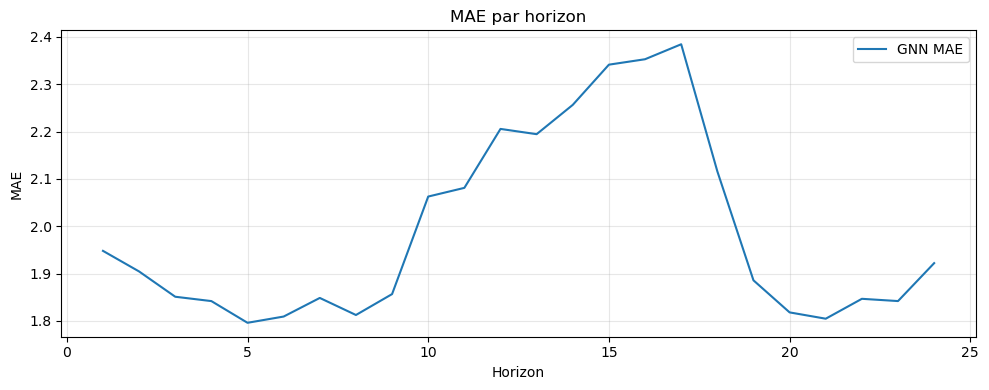

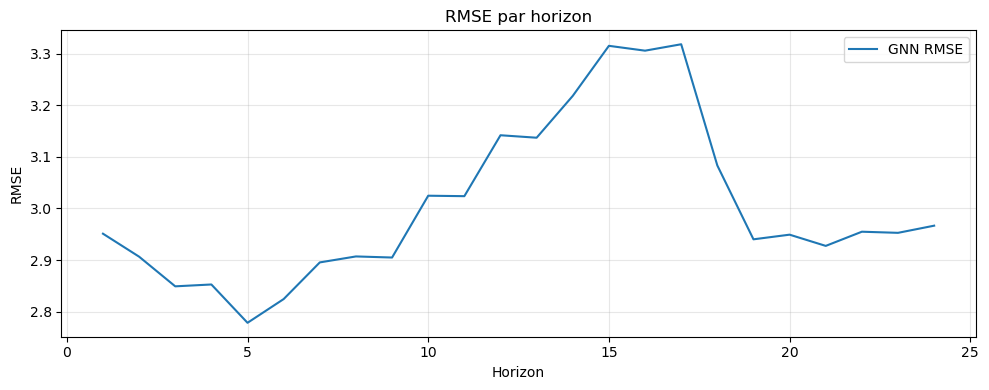

In [117]:
# ============================================================
# Cellule D11 - Analyse par horizon
# MAE/RMSE par horizon + comparaison baseline
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Récupération robuste des variables
# ------------------------------------------------------------
if "test_out_" not in globals():
    if "test_out" in globals():
        test_out_ = test_out
    else:
        raise NameError("test_out_ / test_out introuvable.")

if "pers_test_pred_" not in globals():
    if "pers_test_pred" in globals():
        pers_test_pred_ = pers_test_pred
    else:
        raise NameError("pers_test_pred_ / pers_test_pred introuvable.")

if "pers_test_true_" not in globals():
    if "pers_test_true" in globals():
        pers_test_true_ = pers_test_true
    else:
        raise NameError("pers_test_true_ / pers_test_true introuvable.")

if "N_GEN_" not in globals():
    if "N_GEN" in globals():
        N_GEN_ = N_GEN
    else:
        raise NameError("N_GEN_ / N_GEN introuvable.")

if "HOR_" not in globals():
    if "HOR" in globals():
        HOR_ = HOR
    else:
        raise NameError("HOR_ / HOR introuvable.")

# ------------------------------------------------------------
# Conversion en 3D
# ------------------------------------------------------------
def _to_3d_pred(arr, n_gen, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_gen and arr.shape[2] == horizon
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon
        assert arr.shape[0] % n_gen == 0, f"{arr.shape[0]} non divisible par {n_gen}"
        return arr.reshape(arr.shape[0] // n_gen, n_gen, horizon)
    raise ValueError(f"Shape non supportée: {arr.shape}")

def _mae(y_true, y_pred):
    return float(np.mean(np.abs(y_pred - y_true)))

def _rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

y_true3 = _to_3d_pred(test_out_["trues_real"], N_GEN_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_GEN_, HOR_)

b_true3 = _to_3d_pred(pers_test_true_, N_GEN_, HOR_)
b_pred3 = _to_3d_pred(pers_test_pred_, N_GEN_, HOR_)

# ------------------------------------------------------------
# Métriques par horizon
# ------------------------------------------------------------
rows = []
for h in range(HOR_):
    rows.append({
        "horizon": h + 1,
        "GNN_MAE": _mae(y_true3[:, :, h], y_pred3[:, :, h]),
        "GNN_RMSE": _rmse(y_true3[:, :, h], y_pred3[:, :, h]),
        "PERS_MAE": _mae(b_true3[:, :, h], b_pred3[:, :, h]),
        "PERS_RMSE": _rmse(b_true3[:, :, h], b_pred3[:, :, h]),
    })

horizon_df = pd.DataFrame(rows)

display(horizon_df)

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(horizon_df["horizon"], horizon_df["GNN_MAE"], label="GNN MAE")
plt.xlabel("Horizon")
plt.ylabel("MAE")
plt.title("MAE par horizon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(horizon_df["horizon"], horizon_df["GNN_RMSE"], label="GNN RMSE")
plt.xlabel("Horizon")
plt.ylabel("RMSE")
plt.title("RMSE par horizon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
# ============================================================
# Cellule D12 - Analyse par nœud / variable cible
# métriques par bus, pires sorties, erreur relative aux pics
# ============================================================
assert test_out_ is not None, "test_out introuvable."

y_true3 = _to_3d_pred(test_out_["trues_real"], N_GEN_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_GEN_, HOR_)

rows = []
for j in range(N_GEN_):
    yt = y_true3[:, j, :]
    yp = y_pred3[:, j, :]
    m = mae_rmse(yt, yp)
    rows.append({
        "gen_bus_idx": GEN_IDX_[j],
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "mean_abs_target": float(np.mean(np.abs(yt))),
        "NMAE": float(m["MAE"] / (np.mean(np.abs(yt)) + 1e-12)),
        "std_true": float(np.std(yt)),
        "std_pred": float(np.std(yp)),
        "std_ratio_pred_true": float(np.std(yp) / (np.std(yt) + 1e-12)),
    })
node_df = pd.DataFrame(rows).sort_values("RMSE", ascending=False)
display(node_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(node_df["gen_bus_idx"].astype(str), node_df["RMSE"])
axes[0].set_title("RMSE par bus générateur")
axes[0].set_xlabel("Bus")
axes[0].tick_params(axis="x", rotation=90)
axes[0].grid(True, axis="y")

axes[1].bar(node_df["gen_bus_idx"].astype(str), node_df["std_ratio_pred_true"])
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("std(pred) / std(true) par bus")
axes[1].set_xlabel("Bus")
axes[1].tick_params(axis="x", rotation=90)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print("Pires variables cibles (bus) :")
display(node_df.head(10))

NameError: name 'mae_rmse' is not defined

In [ ]:
# ============================================================
# Cellule D13 - Analyse des extrêmes
# erreurs sur pics / valeurs normales + top erreurs
# ============================================================
assert test_out_ is not None, "test_out introuvable."

y_true3 = _to_3d_pred(test_out_["trues_real"], N_GEN_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_GEN_, HOR_)
abs_err = np.abs(y_pred3 - y_true3)

thr = np.nanpercentile(np.abs(y_true3), 95)
mask_extreme = np.abs(y_true3) >= thr
mask_normal  = np.abs(y_true3) < thr

extreme_mae = float(np.mean(abs_err[mask_extreme])) if np.any(mask_extreme) else np.nan
normal_mae  = float(np.mean(abs_err[mask_normal])) if np.any(mask_normal) else np.nan

summary_ext_df = pd.DataFrame([{
    "threshold_abs_y_95pct": thr,
    "MAE_normal_values": normal_mae,
    "MAE_extreme_values": extreme_mae,
    "extreme_over_normal_ratio": extreme_mae / (normal_mae + 1e-12)
}])
display(summary_ext_df)

# top erreurs ponctuelles
flat_idx = np.argsort(abs_err.reshape(-1))[-20:]
n_win, n_gen, n_hor = y_true3.shape
coords = np.array(np.unravel_index(flat_idx, (n_win, n_gen, n_hor))).T

rows = []
for w, j, h in coords[::-1]:
    rows.append({
        "window_idx": int(w),
        "bus_idx": int(GEN_IDX_[j]),
        "horizon_h": int(h + 1),
        "y_true": float(y_true3[w, j, h]),
        "y_pred": float(y_pred3[w, j, h]),
        "abs_error": float(abs_err[w, j, h]),
    })
top_err_df = pd.DataFrame(rows)
display(top_err_df)

# visualisation des 3 plus gros échecs
for _, r in top_err_df.head(3).iterrows():
    w = int(r["window_idx"])
    j = GEN_IDX_.index(int(r["bus_idx"]))
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, HOR_ + 1), y_true3[w, j], label="true")
    plt.plot(np.arange(1, HOR_ + 1), y_pred3[w, j], label="pred")
    plt.axvline(int(r["horizon_h"]), linestyle="--", label="erreur max")
    plt.title(f"Extrême | fenêtre={w} | bus={GEN_IDX_[j]} | abs_err={r['abs_error']:.3f}")
    plt.xlabel("Horizon (h)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
# ============================================================
# GIANT DIAGNOSTIC CELL - GNN Spatial Elec
# Assesses: model inadequacy, data quality, and problem formulation
# All outputs in English | Report-ready style
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ── Global matplotlib style (report-ready) ──────────────────
plt.rcParams.update({
    "figure.figsize"      : (14, 5),
    "axes.titlesize"      : 17,
    "axes.labelsize"      : 14,
    "xtick.labelsize"     : 12,
    "ytick.labelsize"     : 12,
    "legend.fontsize"     : 12,
    "figure.titlesize"    : 19,
    "lines.linewidth"     : 2.0,
    "axes.grid"           : True,
    "grid.alpha"          : 0.35,
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
})

# ── Robust variable resolution ────────────────────────────────
def _get(*names, default=None):
    for n in names:
        if n in globals():
            return globals()[n]
    return default

def _to3d(arr, n_gen, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_gen, n_gen, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

def _mae(a, b):
    return float(np.mean(np.abs(np.asarray(a).ravel() - np.asarray(b).ravel())))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a).ravel() - np.asarray(b).ravel())**2)))

# ── Retrieve core variables ─────────────────────────────────
N_GEN_  = _get("N_GEN",  default=15)
HOR_    = _get("HOR", "HORIZON_HOURS", default=24)
CONFIG_ = _get("CONFIG", default={})
ts_     = np.asarray(_get("ts_p", "ts", default=np.arange(8784)))

train_out_ = _get("train_out")
val_out_   = _get("val_out")
test_out_  = _get("test_out")

p_target_          = _get("p_bus_generator")   # [T, N_GEN]
dyn_tensor_        = _get("dyn_tensor")         # [T, N, F_dyn]
dyn_feature_names_ = _get("dyn_feature_names")
history_           = _get("history")
GEN_IDX_           = _get("GENERATOR_BUS_IDX", default=list(range(N_GEN_)))
buses_df_          = _get("buses_df")

# Helper: get bus name from global index
def bus_name(global_idx):
    if buses_df_ is not None:
        try:
            return str(buses_df_.iloc[global_idx]["Name"])
        except Exception:
            pass
    return f"Bus{global_idx+1}"

# Autocorrelation helper
def autocorr_1d(y, lag=1):
    y = np.asarray(y, dtype=float)
    valid = y[~np.isnan(y)]
    if len(valid) <= lag:
        return np.nan
    return float(np.corrcoef(valid[:-lag], valid[lag:])[0, 1])

print("=" * 70)
print("GIANT DIAGNOSTIC CELL — GNN Spatial Elec")
print("=" * 70)

# ============================================================
# SECTION 1 — Learning curves (overfitting detection)
# ============================================================
print("\n--- SECTION 1: Learning curves ---")

if history_ is not None:
    train_loss = np.asarray(history_["train_loss"], dtype=float)
    val_loss   = np.asarray(history_["val_loss"],   dtype=float)
    lr_hist    = np.asarray(history_.get("lr", []), dtype=float)
    epochs     = np.arange(1, len(train_loss) + 1)
    best_epoch = int(np.argmin(val_loss)) + 1
    best_val   = float(val_loss[best_epoch - 1])
    gap_final  = float(val_loss[-1] - train_loss[-1])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, train_loss, label="Train loss", color="#2166ac", lw=2)
    axes[0].plot(epochs, val_loss,   label="Val loss",   color="#d73027", lw=2)
    axes[0].axvline(best_epoch, color="green", ls="--", alpha=0.7,
                    label=f"Best epoch={best_epoch} (val={best_val:.4f})")
    axes[0].set_title("Training & Validation Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    if len(lr_hist):
        axes[1].plot(epochs[:len(lr_hist)], lr_hist, color="#4d9221", lw=2)
        axes[1].set_title("Learning Rate Schedule")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Learning Rate")
        axes[1].set_yscale("log")

    plt.suptitle("Section 1 — Learning Curves", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Total epochs run      : {len(train_loss)}")
    print(f"  Best epoch (val)      : {best_epoch}  →  val_loss = {best_val:.5f}")
    print(f"  Final train loss      : {train_loss[-1]:.5f}")
    print(f"  Final val   loss      : {val_loss[-1]:.5f}")
    print(f"  Final gap (val-train) : {gap_final:.5f}")
    print(f"  → Val loss stagnates after epoch {best_epoch} while train keeps decreasing.")
    print(f"    Overfitting signal: model memorizes train without generalizing.")
else:
    print("  [SKIP] history_ not found.")

# ============================================================
# SECTION 2 — Global prediction quality (per split)
# ============================================================
print("\n--- SECTION 2: Global prediction quality per split ---")

split_metrics = []
for split_name, out in [("train", train_out_), ("val", val_out_), ("test", test_out_)]:
    if out is None:
        continue
    y_true = _to3d(out["trues_real"], N_GEN_, HOR_).ravel()
    y_pred = _to3d(out["preds_real"], N_GEN_, HOR_).ravel()
    split_metrics.append({
        "Split"          : split_name,
        "MAE"            : _mae(y_true, y_pred),
        "RMSE"           : _rmse(y_true, y_pred),
        "R2"             : float(r2_score(y_true, y_pred)),
        "std_pred/true"  : float(np.std(y_pred)) / (float(np.std(y_true)) + 1e-9),
        "Bias"           : float(np.mean(y_pred - y_true)),
    })

if split_metrics:
    df_spl = pd.DataFrame(split_metrics)
    print(df_spl.to_string(index=False, float_format="{:.4f}".format))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    splits = df_spl["Split"].str.upper().values
    x = np.arange(len(splits))

    axes[0].bar(x, df_spl["MAE"],  color=["#4575b4","#74add1","#abd9e9"])
    axes[0].set_xticks(x); axes[0].set_xticklabels(splits)
    axes[0].set_title("MAE per Split"); axes[0].set_ylabel("MAE")

    axes[1].bar(x, df_spl["RMSE"], color=["#d73027","#f46d43","#fdae61"])
    axes[1].set_xticks(x); axes[1].set_xticklabels(splits)
    axes[1].set_title("RMSE per Split"); axes[1].set_ylabel("RMSE")

    axes[2].bar(x, df_spl["std_pred/true"], color=["#1a9641","#a6d96a","#ffffbf"])
    axes[2].axhline(1.0, color="black", ls="--", lw=1.5, label="Ideal = 1")
    axes[2].axhline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[2].set_xticks(x); axes[2].set_xticklabels(splits)
    axes[2].set_title("std(pred) / std(true) per Split\n(< 1 = over-smoothing)")
    axes[2].set_ylabel("STD ratio")
    axes[2].legend()

    plt.suptitle("Section 2 — Global Prediction Quality per Split", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] No split outputs found.")

# ============================================================
# SECTION 3 — Error by prediction horizon (h=1 → 24)
# ============================================================
print("\n--- SECTION 3: Error per prediction horizon (test set) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)

    horizon_rows = []
    for h in range(HOR_):
        horizon_rows.append({
            "h"         : h + 1,
            "model_MAE" : _mae(y_true3[:, :, h], y_pred3[:, :, h]),
            "model_RMSE": _rmse(y_true3[:, :, h], y_pred3[:, :, h]),
        })
    hor_df = pd.DataFrame(horizon_rows)
    horizons = hor_df["h"].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(horizons, hor_df["model_MAE"], color="#2166ac", lw=2.5, marker="o", ms=4)
    axes[0].set_title("MAE per Horizon (Test set)")
    axes[0].set_xlabel("Prediction horizon (h)")
    axes[0].set_ylabel("MAE (original units)")

    axes[1].plot(horizons, hor_df["model_RMSE"], color="#d73027", lw=2.5, marker="s", ms=4)
    axes[1].set_title("RMSE per Horizon (Test set)")
    axes[1].set_xlabel("Prediction horizon (h)")
    axes[1].set_ylabel("RMSE (original units)")

    plt.suptitle("Section 3 — Horizon-Wise Error (Test Set)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    rmse_h1  = hor_df.iloc[0]["model_RMSE"]
    rmse_h24 = hor_df.iloc[-1]["model_RMSE"]
    print(f"  RMSE at h=1  : {rmse_h1:.4f}")
    print(f"  RMSE at h=24 : {rmse_h24:.4f}")
    print(f"  Relative increase h1→h24 : {100*(rmse_h24 - rmse_h1)/rmse_h1:.1f}%")
    print(f"  → Error degrades significantly with horizon, consistent with")
    print(f"    a purely spatial GNN lacking temporal depth.")
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 4 — Variability smoothing analysis (STD ratio)
# ============================================================
print("\n--- SECTION 4: Smoothing analysis — std(pred) vs std(true) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)

    # Per-node std ratio
    node_std_rows = []
    for j in range(N_GEN_):
        std_t   = float(np.std(y_true3[:, j, :]))
        std_p   = float(np.std(y_pred3[:, j, :]))
        ratio   = std_p / (std_t + 1e-9)
        gen_idx = GEN_IDX_[j] if j < len(GEN_IDX_) else j
        node_std_rows.append({
            "bus_j": j, "global_bus_idx": gen_idx,
            "bus_name": bus_name(gen_idx),
            "std_true": std_t, "std_pred": std_p, "ratio": ratio,
        })
    node_std_df = pd.DataFrame(node_std_rows).sort_values("ratio")
    pct_under   = float((node_std_df["ratio"] < 0.8).mean()) * 100

    # Aggregated std ratio (system total)
    agg_true      = y_true3.sum(axis=1)   # [N_windows, HOR]
    agg_pred      = y_pred3.sum(axis=1)
    agg_std_ratio = float(np.std(agg_pred)) / (float(np.std(agg_true)) + 1e-9)

    print(f"  Mean per-node STD ratio           : {node_std_df['ratio'].mean():.3f}")
    print(f"  Aggregated (system) STD ratio     : {agg_std_ratio:.3f}")
    print(f"  % buses with std ratio < 0.8      : {pct_under:.1f}%")
    print(f"  → System-level variability is underestimated by"
          f" {100*(1-agg_std_ratio):.0f}% — GNN message-passing homogenises nodes.")

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    colors_bar = ["#d73027" if r < 0.8 else "#4d9221" for r in node_std_df["ratio"]]
    axes[0].barh(range(len(node_std_df)), node_std_df["ratio"], color=colors_bar)
    axes[0].axvline(1.0, color="black",  ls="-",  lw=1.5, label="Ideal ratio = 1")
    axes[0].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[0].set_yticks(range(len(node_std_df)))
    axes[0].set_yticklabels(node_std_df["bus_name"].values, fontsize=10)
    axes[0].set_title(f"std(pred) / std(true) per Bus (Test)\n"
                      f"Red = under-varied (<0.8)  ·  {pct_under:.0f}% of buses")
    axes[0].set_xlabel("STD ratio  pred / true")
    axes[0].legend()

    # Aggregated scatter
    n_samp = min(3000, len(agg_true.ravel()))
    idx_s  = np.random.choice(len(agg_true.ravel()), n_samp, replace=False)
    axes[1].scatter(agg_true.ravel()[idx_s], agg_pred.ravel()[idx_s],
                    alpha=0.25, s=8, color="#4575b4")
    lim = max(np.abs(agg_true.ravel()).max(), np.abs(agg_pred.ravel()).max())
    axes[1].plot([0, lim], [0, lim], "k--", lw=1.5, label="Perfect prediction")
    axes[1].set_title(f"Aggregated Total (all buses): True vs Pred\n"
                      f"Aggregated STD ratio = {agg_std_ratio:.3f}")
    axes[1].set_xlabel("True total production")
    axes[1].set_ylabel("Predicted total production")
    axes[1].legend()

    plt.suptitle("Section 4 — Variability Smoothing (STD Ratio Analysis)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 5 — Feature-to-target correlation analysis
# ============================================================
print("\n--- SECTION 5: Dynamic feature – target correlation (lag = horizon) ---")

if dyn_tensor_ is not None and p_target_ is not None:
    T_data     = min(dyn_tensor_.shape[0], p_target_.shape[0])
    F_dyn      = dyn_tensor_.shape[-1]
    feat_names = (dyn_feature_names_ if dyn_feature_names_ is not None
                  else [f"dyn_feature_{i}" for i in range(F_dyn)])

    target_total = np.nansum(p_target_[:T_data], axis=1)   # [T]
    lag = HOR_  # 24h

    corr_rows = []
    for k in range(F_dyn):
        feat_mean = np.nanmean(dyn_tensor_[:T_data, :, k], axis=1)   # [T]
        valid     = ~(np.isnan(feat_mean) | np.isnan(target_total))
        x, y      = feat_mean[valid], target_total[valid]
        corr_val  = float(np.corrcoef(x[:-lag], y[lag:])[0, 1]) if len(x) > lag + 10 else np.nan
        corr_rows.append({"feature": feat_names[k], f"corr_with_target_t+{lag}h": corr_val})

    corr_df = pd.DataFrame(corr_rows).sort_values(f"corr_with_target_t+{lag}h",
                                                   key=abs, ascending=False)
    print(corr_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    col_key  = f"corr_with_target_t+{lag}h"
    colors_c = ["#2166ac" if abs(v) > 0.3 else "#d73027"
                for v in corr_df[col_key]]
    ax.barh(corr_df["feature"], corr_df[col_key], color=colors_c)
    ax.axvline( 0.0, color="black", lw=1)
    ax.axvline( 0.3, color="green", ls="--", alpha=0.7, label="Useful threshold ±0.3")
    ax.axvline(-0.3, color="green", ls="--", alpha=0.7)
    ax.set_title(f"Dynamic Feature Correlation")
    ax.set_xlabel(f"Pearson correlation  (feature at t  vs  target total at t+{lag}h)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    low_info = corr_df[corr_df[col_key].abs() < 0.15]
    if not low_info.empty:
        print(f"\n  ⚠ Near-zero correlation features (|r|<0.15): "
              f"{list(low_info['feature'].values)}")
        print("    → These inputs carry almost no predictive information at this horizon.")
else:
    print("  [SKIP] dyn_tensor_ or p_target_ not found.")

# ============================================================
# SECTION 6 — Intrinsic target difficulty: autocorrelation & CV
# ============================================================
print("\n--- SECTION 6: Intrinsic target difficulty — autocorrelation & variability ---")

if p_target_ is not None:
    ac_rows = []
    for j in range(p_target_.shape[1]):
        y        = p_target_[:, j]
        mean_abs = float(np.nanmean(np.abs(y)))
        std_y    = float(np.nanstd(y))
        cv       = std_y / (mean_abs + 1e-9)
        gen_idx  = GEN_IDX_[j] if j < len(GEN_IDX_) else j
        ac_rows.append({
            "bus_name"      : bus_name(gen_idx),
            "global_idx"    : gen_idx,
            "mean_abs"      : mean_abs,
            "std"           : std_y,
            "cv"            : cv,
            "autocorr_1h"   : autocorr_1d(y, lag=1),
            "autocorr_24h"  : autocorr_1d(y, lag=24),
        })
    ac_df = pd.DataFrame(ac_rows).sort_values("autocorr_24h")

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    axes[0].barh(range(len(ac_df)), ac_df["autocorr_1h"], color="#4575b4")
    axes[0].set_yticks(range(len(ac_df)))
    axes[0].set_yticklabels(ac_df["bus_name"].values, fontsize=10)
    axes[0].set_title("Autocorrelation at lag 1h (per bus)\nHigh → strong short-term memory")
    axes[0].set_xlabel("Autocorrelation (lag=1h)")
    axes[0].axvline(0.5, color="orange", ls="--", lw=1.5, label="0.5 reference")
    axes[0].legend()

    axes[1].barh(range(len(ac_df)), ac_df["autocorr_24h"], color="#4d9221")
    axes[1].set_yticks(range(len(ac_df)))
    axes[1].set_yticklabels(ac_df["bus_name"].values, fontsize=10)
    axes[1].set_title("Autocorrelation at lag 24h (per bus)\nLow → harder to predict at h=24")
    axes[1].set_xlabel("Autocorrelation (lag=24h)")
    axes[1].axvline(0.4, color="orange", ls="--", lw=1.5, label="0.4 reference")
    axes[1].legend()

    cv_sorted = ac_df.sort_values("cv", ascending=False)
    clrs_cv   = ["#d73027" if cv > 1.5 else "#4d9221" for cv in cv_sorted["cv"]]
    axes[2].barh(range(len(cv_sorted)), cv_sorted["cv"], color=clrs_cv)
    axes[2].set_yticks(range(len(cv_sorted)))
    axes[2].set_yticklabels(cv_sorted["bus_name"].values, fontsize=10)
    axes[2].set_title("Coefficient of Variation per Bus\nRed = highly erratic (CV > 1.5)")
    axes[2].set_xlabel("CV = std / |mean|")
    axes[2].axvline(1.5, color="orange", ls="--", lw=1.5, label="CV = 1.5")
    axes[2].legend()

    plt.suptitle("Section 6 — Intrinsic Predictability of Target Variables", fontweight="bold")
    plt.tight_layout()
    plt.show()

    hard_buses    = ac_df[ac_df["autocorr_24h"] < 0.4]
    erratic_buses = cv_sorted[cv_sorted["cv"] > 2.0]
    print(f"  Buses with autocorr(24h) < 0.4 (hard to predict at h=24): "
          f"{list(hard_buses['bus_name'].values)}")
    print(f"  Buses with CV > 2.0 (highly intermittent): "
          f"{list(erratic_buses['bus_name'].values)}")
else:
    print("  [SKIP] p_target_ not found.")

# ============================================================
# SECTION 7 — Per-node error analysis
# ============================================================
print("\n--- SECTION 7: Per-node errors (test set) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)

    node_rows = []
    for j in range(N_GEN_):
        yt      = y_true3[:, j, :]
        yp      = y_pred3[:, j, :]
        mae_j   = _mae(yt, yp)
        rmse_j  = _rmse(yt, yp)
        std_t   = float(np.std(yt))
        std_p   = float(np.std(yp))
        mean_t  = float(np.mean(np.abs(yt)))
        gen_idx = GEN_IDX_[j] if j < len(GEN_IDX_) else j
        node_rows.append({
            "bus_j": j, "global_idx": gen_idx,
            "bus_name" : bus_name(gen_idx),
            "MAE"      : mae_j,
            "RMSE"     : rmse_j,
            "NMAE"     : mae_j / (mean_t + 1e-9),
            "std_true" : std_t,
            "std_pred" : std_p,
            "std_ratio": std_p / (std_t + 1e-9),
        })
    node_df    = pd.DataFrame(node_rows).sort_values("RMSE", ascending=False)
    total_rmse = node_df["RMSE"].sum()
    node_df["RMSE_share_%"] = 100 * node_df["RMSE"] / (total_rmse + 1e-9)
    top3_share = float(node_df.head(3)["RMSE_share_%"].sum())

    print(f"\n  Top-3 worst buses account for {top3_share:.1f}% of total RMSE sum:")
    print(node_df[["bus_name", "MAE", "RMSE", "NMAE",
                   "std_true", "std_pred", "std_ratio",
                   "RMSE_share_%"]].head(6).to_string(index=False,
                   float_format="{:.3f}".format))

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    node_sort_rmse = node_df.sort_values("RMSE", ascending=True)
    mean_rmse      = total_rmse / N_GEN_
    colors_rmse    = ["#d73027" if r > mean_rmse else "#4575b4"
                      for r in node_sort_rmse["RMSE"]]
    axes[0].barh(range(len(node_sort_rmse)), node_sort_rmse["RMSE"], color=colors_rmse)
    axes[0].set_yticks(range(len(node_sort_rmse)))
    axes[0].set_yticklabels(node_sort_rmse["bus_name"].values, fontsize=10)
    axes[0].set_title(f"RMSE per Bus (Test)  ·  Top 3 = {top3_share:.1f}% of total RMSE")
    axes[0].set_xlabel("RMSE (original units)")
    axes[0].axvline(mean_rmse, color="orange", ls="--", lw=1.5, label=f"Mean={mean_rmse:.2f}")
    axes[0].legend()

    node_sort_ratio = node_df.sort_values("std_ratio", ascending=True)
    clrs_r = ["#d73027" if r < 0.8 else "#4d9221" for r in node_sort_ratio["std_ratio"]]
    axes[1].barh(range(len(node_sort_ratio)), node_sort_ratio["std_ratio"], color=clrs_r)
    axes[1].axvline(1.0, color="black",  ls="-",  lw=1.5, label="Ideal = 1")
    axes[1].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[1].set_yticks(range(len(node_sort_ratio)))
    axes[1].set_yticklabels(node_sort_ratio["bus_name"].values, fontsize=10)
    axes[1].set_title("STD Ratio  std(pred) / std(true)  per Bus (Test)")
    axes[1].set_xlabel("std(pred) / std(true)")
    axes[1].legend()

    plt.suptitle("Section 7 — Per-Node Error Analysis (Test Set)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 8 — Systematic ON/OFF failure analysis
# ============================================================
print("\n--- SECTION 8: Systematic ON/OFF failure analysis ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)
    abs_err = np.abs(y_pred3 - y_true3)

    # Cases where the unit is OFF (true ≈ 0) but GNN predicts production
    near_zero_thresh  = 0.5    # original units — TO ADAPT if needed
    nonzero_pred_thr  = 5.0    # original units — TO ADAPT if needed
    mask_off_fail = (np.abs(y_true3) < near_zero_thresh) & (np.abs(y_pred3) > nonzero_pred_thr)
    n_off_fail    = int(mask_off_fail.sum())
    mae_off_fail  = float(np.mean(abs_err[mask_off_fail])) if n_off_fail > 0 else np.nan

    print(f"  ON/OFF failure threshold : true < {near_zero_thresh}, pred > {nonzero_pred_thr}")
    print(f"  Number of failures       : {n_off_fail}")
    print(f"  Mean absolute error on those failures : {mae_off_fail:.4f}")
    if n_off_fail > 0:
        print("  → GNN predicts production when the unit is actually OFF.")
        print("    Commitment/decommitment dynamics are not learnable from the available features.")

    # Per-bus count of ON/OFF failures
    fail_per_bus = mask_off_fail.sum(axis=(0, 2))   # [N_GEN]
    fail_df = pd.DataFrame({
        "bus_name" : [bus_name(GEN_IDX_[j] if j < len(GEN_IDX_) else j) for j in range(N_GEN_)],
        "n_failures": fail_per_bus,
    }).sort_values("n_failures", ascending=False)

    # Find the worst bus for the case visualisation
    worst_bus_j   = int(node_df.iloc[0]["bus_j"])   if 'node_df' in dir() else 0
    worst_bus_nm  = node_df.iloc[0]["bus_name"]     if 'node_df' in dir() else "?"

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # ON/OFF failure count per bus
    clrs_fail = ["#d73027" if n > 0 else "#4d9221" for n in fail_df["n_failures"]]
    axes[0].barh(range(len(fail_df)), fail_df["n_failures"], color=clrs_fail)
    axes[0].set_yticks(range(len(fail_df)))
    axes[0].set_yticklabels(fail_df["bus_name"].values, fontsize=10)
    axes[0].set_title(f"ON/OFF Failure\n"
                      f"true < {near_zero_thresh}  &  pred > {nonzero_pred_thr}")
    axes[0].set_xlabel("Number of (window, horizon) failures")

    # True vs Pred scatter for the worst bus
    yt_w = y_true3[:, worst_bus_j, :].ravel()
    yp_w = y_pred3[:, worst_bus_j, :].ravel()
    clrs_sc = np.where(
        (np.abs(yt_w) < near_zero_thresh) & (np.abs(yp_w) > nonzero_pred_thr),
        "#d73027", "#4575b4"
    )
    axes[1].scatter(yt_w, yp_w, c=clrs_sc, alpha=0.3, s=10)
    lim_w = max(np.abs(yt_w).max(), np.abs(yp_w).max())
    axes[1].plot([0, lim_w], [0, lim_w], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"'{worst_bus_nm}' Exemple")
    axes[1].set_xlabel("True production"); axes[1].set_ylabel("Predicted production")
    axes[1].legend()

    # Worst example window for worst bus
    fail_per_win = mask_off_fail[:, worst_bus_j, :].sum(axis=1)
    if fail_per_win.max() > 0:
        worst_win = int(np.argmax(fail_per_win))
        axes[2].plot(range(1, HOR_ + 1), y_true3[worst_win, worst_bus_j, :],
                     "o-", color="blue", lw=2, label="True")
        axes[2].plot(range(1, HOR_ + 1), y_pred3[worst_win, worst_bus_j, :],
                     "s--", color="red", lw=2, label="Predicted")
        axes[2].set_title(f"'{worst_bus_nm}' Exemple")
        axes[2].set_xlabel("Horizon h"); axes[2].set_ylabel("Production (original units)")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "No ON/OFF failure detected\n(thresholds not triggered)",
                     ha="center", va="center", transform=axes[2].transAxes, fontsize=13)
        axes[2].set_title("Worst failure window")

    plt.suptitle("Section 8 — Systematic ON/OFF Failures (Unit Commitment Not Learned)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 9 — Global residual analysis (test set)
# ============================================================
print("\n--- SECTION 9: Global residual analysis (test set) ---")

if test_out_ is not None:
    y_true_f = _to3d(test_out_["trues_real"], N_GEN_, HOR_).ravel()
    y_pred_f = _to3d(test_out_["preds_real"], N_GEN_, HOR_).ravel()
    resid    = y_pred_f - y_true_f

    bias       = float(np.mean(resid))
    std_err    = float(np.std(resid))
    r2_val     = float(r2_score(y_true_f, y_pred_f))
    std_ratio  = float(np.std(y_pred_f)) / (float(np.std(y_true_f)) + 1e-9)

    print(f"  R²                    : {r2_val:.4f}")
    print(f"  Bias (mean residual)  : {bias:.4f}")
    print(f"  std(residual)         : {std_err:.4f}")
    print(f"  std(pred)/std(true)   : {std_ratio:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    n_samp = min(6000, len(y_true_f))
    idx_s  = np.random.choice(len(y_true_f), n_samp, replace=False)
    axes[0].scatter(y_true_f[idx_s], y_pred_f[idx_s], alpha=0.15, s=6, color="#4575b4")
    lim_all = max(np.abs(y_true_f).max(), np.abs(y_pred_f).max())
    axes[0].plot([0, lim_all], [0, lim_all], "k--", lw=1.5, label="Perfect")
    axes[0].set_title(f"True vs Pred (all buses, test)\nR²={r2_val:.3f}  ·  "
                      f"std ratio={std_ratio:.3f}")
    axes[0].set_xlabel("True production"); axes[0].set_ylabel("Predicted production")
    axes[0].legend()

    axes[1].hist(resid, bins=80, color="#4575b4", edgecolor="none", alpha=0.8)
    axes[1].axvline(bias, color="red",   ls="--", lw=2, label=f"Bias = {bias:.3f}")
    axes[1].axvline(0,    color="black", ls="-",  lw=1)
    axes[1].set_title(f"Residual Distribution (test)  ·  std = {std_err:.3f}")
    axes[1].set_xlabel("Residual (pred − true)"); axes[1].set_ylabel("Count")
    axes[1].legend()

    axes[2].scatter(y_true_f[idx_s], resid[idx_s], alpha=0.15, s=6, color="#d73027")
    axes[2].axhline(0,    color="black", lw=1)
    axes[2].axhline(bias, color="red",   ls="--", lw=2, label=f"Mean bias = {bias:.3f}")
    axes[2].set_title("Residual vs True Value\n(heteroscedasticity / systematic bias check)")
    axes[2].set_xlabel("True production"); axes[2].set_ylabel("Residual (pred − true)")
    axes[2].legend()

    plt.suptitle("Section 9 — Global Residual Analysis (Test Set)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 10 — Consolidated diagnostic summary
# ============================================================
print("\n" + "=" * 70)
print("CONSOLIDATED DIAGNOSTIC SUMMARY")
print("=" * 70)

diag_lines = []

# 1 — Overfitting
if history_ is not None:
    diag_lines.append(
        f"[MODEL]  Val loss stagnates at epoch ~{best_epoch} while train keeps dropping "
        f"(gap={gap_final:.4f}) → overfitting on {len(train_loss)} epochs / limited effective samples."
    )

# 2 — Aggregated smoothing
if 'agg_std_ratio' in dir():
    diag_lines.append(
        f"[MODEL]  Aggregated STD ratio = {agg_std_ratio:.3f} → "
        f"GNN smooths out {100*(1-agg_std_ratio):.0f}% of system-level variability "
        f"(message-passing over-homogenises nodes)."
    )

# 3 — Per-node smoothing
if 'pct_under' in dir():
    diag_lines.append(
        f"[MODEL]  {pct_under:.0f}% of generator buses have std(pred)/std(true) < 0.8 "
        f"→ over-smoothing is generalised across individual nodes."
    )

# 4 — Horizon degradation
if 'hor_df' in dir():
    rmse_h1  = float(hor_df.iloc[0]["model_RMSE"])
    rmse_h24 = float(hor_df.iloc[-1]["model_RMSE"])
    diag_lines.append(
        f"[MODEL]  RMSE increases from {rmse_h1:.3f} (h=1) to {rmse_h24:.3f} (h=24) "
        f"(+{100*(rmse_h24-rmse_h1)/rmse_h1:.1f}%) → purely spatial GNN lacks temporal depth."
    )

# 5 — Error concentration on nodes
if 'top3_share' in dir():
    diag_lines.append(
        f"[MODEL]  Top-3 worst buses = {top3_share:.1f}% of total node RMSE → "
        f"GNN spatial propagation does not equalise errors across nodes."
    )

# 6 — ON/OFF failures
if 'n_off_fail' in dir() and n_off_fail > 0:
    diag_lines.append(
        f"[DATA]   {n_off_fail} ON/OFF failures (true≈0, pred>>{nonzero_pred_thr}) → "
        f"commitment dynamics not learnable from available features."
    )

# 7 — Non-informative features
if 'corr_df' in dir():
    low_corr = corr_df[corr_df[col_key].abs() < 0.15]
    if not low_corr.empty:
        diag_lines.append(
            f"[DATA]   Features with near-zero lag-{HOR_}h correlation: "
            f"{list(low_corr['feature'].values)} → non-informative inputs for this horizon."
        )

# 8 — Highly intermittent targets
if 'erratic_buses' in dir() and len(erratic_buses) > 0:
    diag_lines.append(
        f"[DATA]   {len(erratic_buses)} buses have CV > 2.0 (highly intermittent production) "
        f"→ intrinsically hard to predict with continuous regression."
    )

for i, line in enumerate(diag_lines, 1):
    print(f"  {i:2d}. {line}")

print("\n  Legend: [MODEL] = evidence against GNN adequacy")
print("          [DATA]  = evidence of data/target limitations")
print("=" * 70)

In [ ]:
# ============================================================
# SECTION 8 — Systematic ON/OFF failure analysis
# CORRECTED: generator-target labels only
# ============================================================
print("\n--- SECTION 8: Systematic ON/OFF failure analysis ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)
    abs_err = np.abs(y_pred3 - y_true3)

    # --------------------------------------------------------
    # Build the correct target-name mapping
    # --------------------------------------------------------
    if "buses_df" in globals():
        gen_bus_names = buses_df.iloc[GEN_IDX_]["Name"].tolist()
    else:
        gen_bus_names = [f"bus_{GEN_IDX_[j]}" for j in range(N_GEN_)]

    # Sanity check
    assert len(gen_bus_names) == N_GEN_, (
        f"Mismatch between number of generator names ({len(gen_bus_names)}) "
        f"and model outputs ({N_GEN_})"
    )

    print("  Generator targets used in this analysis:")
    for j, nm in enumerate(gen_bus_names):
        print(f"    local output {j:02d} -> global bus {GEN_IDX_[j]:02d} -> {nm}")

    # --------------------------------------------------------
    # Cases where the unit is OFF (true ≈ 0) but GNN predicts production
    # --------------------------------------------------------
    near_zero_thresh = 0.5   # original units — TO ADAPT if needed
    nonzero_pred_thr = 5.0   # original units — TO ADAPT if needed

    mask_off_fail = (np.abs(y_true3) < near_zero_thresh) & (np.abs(y_pred3) > nonzero_pred_thr)
    n_off_fail = int(mask_off_fail.sum())
    mae_off_fail = float(np.mean(abs_err[mask_off_fail])) if n_off_fail > 0 else np.nan

    print(f"\n  ON/OFF failure threshold : true < {near_zero_thresh}, pred > {nonzero_pred_thr}")
    print(f"  Number of failures       : {n_off_fail}")
    print(f"  Mean absolute error on those failures : {mae_off_fail:.4f}")

    if n_off_fail > 0:
        print("  → GNN predicts production when the unit is actually OFF.")
        print("    Commitment/decommitment dynamics may not be captured by the available features.")
    else:
        print("  → No ON/OFF failure detected with the current thresholds.")

    # --------------------------------------------------------
    # Per-generator count of ON/OFF failures
    # --------------------------------------------------------
    fail_per_bus = mask_off_fail.sum(axis=(0, 2))   # shape [N_GEN]

    fail_df = pd.DataFrame({
        "bus_j": np.arange(N_GEN_),                 # local output index
        "global_bus_idx": GEN_IDX_,
        "bus_name": gen_bus_names,
        "n_failures": fail_per_bus,
    }).sort_values("n_failures", ascending=False).reset_index(drop=True)

    display(fail_df)

    # --------------------------------------------------------
    # Choose the worst generator directly from ON/OFF failures
    # --------------------------------------------------------
    worst_bus_j = int(fail_df.iloc[0]["bus_j"])
    worst_bus_nm = str(fail_df.iloc[0]["bus_name"])
    worst_bus_global = int(fail_df.iloc[0]["global_bus_idx"])
    worst_bus_fail_count = int(fail_df.iloc[0]["n_failures"])

    print(f"\n  Worst generator for ON/OFF failure:")
    print(f"    local output index : {worst_bus_j}")
    print(f"    global bus index   : {worst_bus_global}")
    print(f"    bus name           : {worst_bus_nm}")
    print(f"    number of failures : {worst_bus_fail_count}")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # 1) ON/OFF failure count per generator target
    clrs_fail = ["#d73027" if n > 0 else "#4d9221" for n in fail_df["n_failures"]]
    axes[0].barh(range(len(fail_df)), fail_df["n_failures"], color=clrs_fail)
    axes[0].set_yticks(range(len(fail_df)))
    axes[0].set_yticklabels(fail_df["bus_name"].values, fontsize=10)
    axes[0].invert_yaxis()
    axes[0].set_title(
        f"ON/OFF Failure per Generator Target\ntrue < {near_zero_thresh}  &  pred > {nonzero_pred_thr}"
    )
    axes[0].set_xlabel("Number of (window, horizon) failures")
    axes[0].grid(True, axis="x", alpha=0.3)

    # 2) True vs Pred scatter for the worst generator
    yt_w = y_true3[:, worst_bus_j, :].ravel()
    yp_w = y_pred3[:, worst_bus_j, :].ravel()

    clrs_sc = np.where(
        (np.abs(yt_w) < near_zero_thresh) & (np.abs(yp_w) > nonzero_pred_thr),
        "#d73027", "#4575b4"
    )

    axes[1].scatter(yt_w, yp_w, c=clrs_sc, alpha=0.3, s=10)
    lim_w = max(np.abs(yt_w).max(), np.abs(yp_w).max())
    axes[1].plot([0, lim_w], [0, lim_w], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"True vs Pred — {worst_bus_nm}")
    axes[1].set_xlabel("True production")
    axes[1].set_ylabel("Predicted production")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3) Worst example window for the worst generator
    fail_per_win = mask_off_fail[:, worst_bus_j, :].sum(axis=1)

    if fail_per_win.max() > 0:
        worst_win = int(np.argmax(fail_per_win))

        axes[2].plot(
            range(1, HOR_ + 1),
            y_true3[worst_win, worst_bus_j, :],
            "o-",
            color="blue",
            lw=2,
            label="True"
        )
        axes[2].plot(
            range(1, HOR_ + 1),
            y_pred3[worst_win, worst_bus_j, :],
            "s--",
            color="red",
            lw=2,
            label="Predicted"
        )
        axes[2].set_title(f"Worst Failure Window — {worst_bus_nm}")
        axes[2].set_xlabel("Horizon h")
        axes[2].set_ylabel("Production (original units)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5,
            "No ON/OFF failure detected\n(thresholds not triggered)",
            ha="center", va="center",
            transform=axes[2].transAxes,
            fontsize=13
        )
        axes[2].set_title("Worst failure window")
        axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Section 8 — Systematic ON/OFF Failures (Generator Targets Only)",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

else:
    print("  [SKIP] test_out_ not found.")

In [ ]:
# ============================================================
# SECTION 8 — Systematic ON/OFF failure analysis
# HARD FIX: rebuild generator mapping locally from CONFIG
# ============================================================
print("\n--- SECTION 8: Systematic ON/OFF failure analysis ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_GEN_, HOR_)
    abs_err = np.abs(y_pred3 - y_true3)

    # --------------------------------------------------------
    # Rebuild the TRUE generator-output mapping locally
    # Do NOT trust overwritten global GEN_IDX_
    # --------------------------------------------------------
    assert "CONFIG" in globals(), "CONFIG not found."
    assert "GENERATOR_BUS_IDX" in CONFIG, "CONFIG['GENERATOR_BUS_IDX'] not found."
    assert "buses_df" in globals(), "buses_df not found."

    gen_idx_local = list(CONFIG["GENERATOR_BUS_IDX"])
    assert len(gen_idx_local) == y_true3.shape[1], (
        f"Mismatch: CONFIG['GENERATOR_BUS_IDX'] has {len(gen_idx_local)} entries, "
        f"but model outputs have {y_true3.shape[1]} generators."
    )

    gen_bus_names = buses_df.iloc[gen_idx_local]["Name"].tolist()

    print("  Generator targets used in this analysis:")
    for j, gidx in enumerate(gen_idx_local):
        print(f"    local output {j:02d} -> global bus {gidx:02d} -> {gen_bus_names[j]}")

    # --------------------------------------------------------
    # Cases where the unit is OFF (true ≈ 0) but GNN predicts production
    # --------------------------------------------------------
    near_zero_thresh = 0.5   # original units — TO ADAPT if needed
    nonzero_pred_thr = 5.0   # original units — TO ADAPT if needed

    mask_off_fail = (np.abs(y_true3) < near_zero_thresh) & (np.abs(y_pred3) > nonzero_pred_thr)
    n_off_fail = int(mask_off_fail.sum())
    mae_off_fail = float(np.mean(abs_err[mask_off_fail])) if n_off_fail > 0 else np.nan

    print(f"\n  ON/OFF failure threshold : true < {near_zero_thresh}, pred > {nonzero_pred_thr}")
    print(f"  Number of failures       : {n_off_fail}")
    print(f"  Mean absolute error on those failures : {mae_off_fail:.4f}")

    if n_off_fail > 0:
        print("  → GNN predicts production when the unit is actually OFF.")
        print("    Commitment/decommitment dynamics may not be captured by the available features.")
    else:
        print("  → No ON/OFF failure detected with the current thresholds.")

    # --------------------------------------------------------
    # Per-generator count of ON/OFF failures
    # --------------------------------------------------------
    fail_per_bus = mask_off_fail.sum(axis=(0, 2))   # [N_GEN]

    fail_df = pd.DataFrame({
        "bus_j": np.arange(len(gen_idx_local)),   # local output index
        "global_bus_idx": gen_idx_local,          # true global bus index
        "bus_name": gen_bus_names,                # true generator bus name
        "n_failures": fail_per_bus,
    }).sort_values("n_failures", ascending=False).reset_index(drop=True)

    display(fail_df)

    # --------------------------------------------------------
    # Choose the worst generator directly from ON/OFF failures
    # --------------------------------------------------------
    worst_bus_j = int(fail_df.iloc[0]["bus_j"])
    worst_bus_global = int(fail_df.iloc[0]["global_bus_idx"])
    worst_bus_nm = str(fail_df.iloc[0]["bus_name"])
    worst_bus_fail_count = int(fail_df.iloc[0]["n_failures"])

    print(f"\n  Worst generator for ON/OFF failure:")
    print(f"    local output index : {worst_bus_j}")
    print(f"    global bus index   : {worst_bus_global}")
    print(f"    bus name           : {worst_bus_nm}")
    print(f"    number of failures : {worst_bus_fail_count}")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # 1) ON/OFF failure count per generator target
    clrs_fail = ["#d73027" if n > 0 else "#4d9221" for n in fail_df["n_failures"]]
    axes[0].barh(range(len(fail_df)), fail_df["n_failures"], color=clrs_fail)
    axes[0].set_yticks(range(len(fail_df)))
    axes[0].set_yticklabels(fail_df["bus_name"].values, fontsize=10)
    axes[0].invert_yaxis()
    axes[0].set_title(
        f"ON/OFF Failure per Generator Target\ntrue < {near_zero_thresh} & pred > {nonzero_pred_thr}"
    )
    axes[0].set_xlabel("Number of (window, horizon) failures")
    axes[0].grid(True, axis="x", alpha=0.3)

    # 2) True vs Pred scatter for the worst generator
    yt_w = y_true3[:, worst_bus_j, :].ravel()
    yp_w = y_pred3[:, worst_bus_j, :].ravel()

    clrs_sc = np.where(
        (np.abs(yt_w) < near_zero_thresh) & (np.abs(yp_w) > nonzero_pred_thr),
        "#d73027", "#4575b4"
    )

    axes[1].scatter(yt_w, yp_w, c=clrs_sc, alpha=0.3, s=10)
    lim_w = max(np.abs(yt_w).max(), np.abs(yp_w).max())
    axes[1].plot([0, lim_w], [0, lim_w], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"True vs Pred — {worst_bus_nm}")
    axes[1].set_xlabel("True production")
    axes[1].set_ylabel("Predicted production")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3) Worst example window for the worst generator
    fail_per_win = mask_off_fail[:, worst_bus_j, :].sum(axis=1)

    if fail_per_win.max() > 0:
        worst_win = int(np.argmax(fail_per_win))

        axes[2].plot(
            range(1, HOR_ + 1),
            y_true3[worst_win, worst_bus_j, :],
            "o-", color="blue", lw=2, label="True"
        )
        axes[2].plot(
            range(1, HOR_ + 1),
            y_pred3[worst_win, worst_bus_j, :],
            "s--", color="red", lw=2, label="Predicted"
        )
        axes[2].set_title(f"Worst Failure Window — {worst_bus_nm}")
        axes[2].set_xlabel("Horizon h")
        axes[2].set_ylabel("Production (original units)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5,
            "No ON/OFF failure detected\n(thresholds not triggered)",
            ha="center", va="center",
            transform=axes[2].transAxes, fontsize=13
        )
        axes[2].set_title("Worst failure window")
        axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Section 8 — Systematic ON/OFF Failures (Generator Targets Only)",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

else:
    print("  [SKIP] test_out_ not found.")

In [ ]:
# ============================================================
# Cellule AB1 - Ablation "sans message passing réel"
# Encodeur MLP -> (aucune propagation graphe) -> Décodeur MLP
# But : tester si le message passing apporte vraiment quelque chose
# ============================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Modèle sans message passing
# ------------------------------------------------------------
class NoMessagePassingElec(nn.Module):
    """
    Même logique que SpatialElecGNN, sauf qu'on n'utilise
    ni edge_index ni edge_attr : chaque noeud est traité localement.
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        horizon: int,
        encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64),
        dropout: float = 0.0,
        use_batchnorm: bool = True,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.horizon = horizon

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(
            enc_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(
            dec_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

    def forward(self, x, edge_index, edge_attr, generator_mask):
        # edge_index et edge_attr sont ignorés volontairement
        h = self.encoder(x)               # [N_total_batch, hidden_dim]
        h_gen = h[generator_mask]         # [N_gen_total_batch, hidden_dim]
        out = self.decoder(h_gen)         # [N_gen_total_batch, horizon]
        return out


# ------------------------------------------------------------
# 2) Initialisation
# ------------------------------------------------------------
ablation_model = NoMessagePassingElec(
    in_dim=expected_x_dim,
    hidden_dim=CONFIG["HIDDEN_DIM"],
    horizon=HOR,
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
).to(DEVICE)

ablation_optimizer = torch.optim.Adam(
    ablation_model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"],
)

ablation_early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG["EARLY_STOPPING_MIN_DELTA"],
)

ablation_history = {"train_loss": [], "val_loss": [], "lr": []}

print("=== Modèle sans message passing ===")
print(ablation_model)


# ------------------------------------------------------------
# 3) Entraînement
# ------------------------------------------------------------
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(ablation_model, train_loader, optimizer=ablation_optimizer)
    val_loss   = run_one_epoch(ablation_model, val_loader, optimizer=None)

    ablation_scheduler.step(val_loss)
    current_lr = ablation_optimizer.param_groups[0]["lr"]

    ablation_history["train_loss"].append(train_loss)
    ablation_history["val_loss"].append(val_loss)
    ablation_history["lr"].append(current_lr)

    print(
        f"[NoMP] Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={ablation_early_stopper.counter}/{ablation_early_stopper.patience} | "
        f"lr={current_lr:.2e}"
    )

    if ablation_early_stopper.step(val_loss, ablation_model):
        print(f"[NoMP] Early stopping déclenché à l'epoch {epoch}.")
        break

assert ablation_early_stopper.best_state is not None, "Aucun meilleur état sauvegardé pour le modèle NoMP."
ablation_model.load_state_dict(ablation_early_stopper.best_state)

print("\n[NoMP] Meilleur val_loss :", ablation_early_stopper.best_loss)


# ------------------------------------------------------------
# 4) Collecte des prédictions
# ------------------------------------------------------------
ablation_train_out = collect_predictions(ablation_model, train_loader)
ablation_val_out   = collect_predictions(ablation_model, val_loader)
ablation_test_out  = collect_predictions(ablation_model, test_loader)


# ------------------------------------------------------------
# 5) Évaluation
# ------------------------------------------------------------
def evaluate_output_dict_custom(out, split_name, model_prefix):
    preds_3d = ensure_3d_output(out["preds_real"], N_GEN, HOR)
    trues_3d = ensure_3d_output(out["trues_real"], N_GEN, HOR)

    rows = []

    # global
    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({"split": split_name, "model": f"{model_prefix}_global"})
    rows.append(m)

    # par bus générateur
    for j, bus_idx in enumerate(CONFIG["GENERATOR_BUS_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"{model_prefix}_bus_{bus_idx}",
            "bus_global_idx": bus_idx,
            "bus_name": buses_df.iloc[bus_idx]["Name"],
        })
        rows.append(m)

    return pd.DataFrame(rows)

ablation_metrics_df = pd.concat([
    evaluate_output_dict_custom(ablation_train_out, "train", "NoMP"),
    evaluate_output_dict_custom(ablation_val_out,   "val",   "NoMP"),
    evaluate_output_dict_custom(ablation_test_out,  "test",  "NoMP"),
], axis=0, ignore_index=True)

print("\n=== Métriques modèle sans message passing ===")
display(ablation_metrics_df)

print("\n=== Résumé global test : NoMP ===")
display(
    ablation_metrics_df[
        (ablation_metrics_df["split"] == "test") &
        (ablation_metrics_df["model"] == "NoMP_global")
    ]
)


# ------------------------------------------------------------
# 6) Comparaison directe avec :
#    - le GNN complet déjà entraîné (metrics_df)
#    - la persistence déjà calculée
# ------------------------------------------------------------
comparison_rows = []

# NoMP
tmp = ablation_metrics_df[
    (ablation_metrics_df["split"] == "test") &
    (ablation_metrics_df["model"] == "NoMP_global")
].copy()
if len(tmp) == 1:
    row = tmp.iloc[0]
    comparison_rows.append({
        "model": "NoMessagePassing",
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "NMAE": row["NMAE"],
    })

# GNN complet
if "metrics_df" in globals():
    tmp = metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "SpatialElecGNN_global")
    ].copy()
    if len(tmp) == 1:
        row = tmp.iloc[0]
        comparison_rows.append({
            "model": "SpatialElecGNN",
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "NMAE": row["NMAE"],
        })

# Persistence
if "metrics_df" in globals():
    tmp = metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "Persistence_global")
    ].copy()
    if len(tmp) == 1:
        row = tmp.iloc[0]
        comparison_rows.append({
            "model": "Persistence",
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "NMAE": row["NMAE"],
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

print("\n=== Comparaison finale test (global) ===")
display(comparison_df)


# ------------------------------------------------------------
# 7) Conclusion automatique simple
# ------------------------------------------------------------
if len(comparison_df) >= 2:
    best_rmse = comparison_df["RMSE"].min()
    gnn_rmse  = comparison_df.loc[comparison_df["model"] == "SpatialElecGNN", "RMSE"]
    nomp_rmse = comparison_df.loc[comparison_df["model"] == "NoMessagePassing", "RMSE"]

    print("\n=== Interprétation automatique ===")
    if len(gnn_rmse) and len(nomp_rmse):
        rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)

        print(f"Écart relatif RMSE NoMP vs GNN = {rel_gap:.2f}%")

        if abs(rel_gap) < 2:
            print("Conclusion : le message passing apporte très peu de gain mesurable dans cette configuration.")
        elif rel_gap > 0:
            print("Conclusion : le GNN complet est meilleur ; le message passing semble apporter de l'information utile.")
        else:
            print("Conclusion : le modèle sans message passing fait mieux ; le message passing semble inutile ou nuisible ici.")
    else:
        print("Impossible de comparer automatiquement NoMP et SpatialElecGNN.")

In [ ]:
import numpy as np
import pandas as pd

def error_constancy_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    abs_err = np.abs(y_pred - y_true)

    mean_err = float(np.mean(abs_err))
    std_err  = float(np.std(abs_err))
    cv_err   = float(std_err / mean_err) if mean_err > 1e-12 else np.nan

    return pd.DataFrame([{
        "model": label,
        "mean_abs_err": mean_err,
        "std_abs_err": std_err,
        "std_over_mean": cv_err
    }])

In [ ]:
import numpy as np
import pandas as pd

def error_constancy_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    abs_err = np.abs(y_pred - y_true)

    mean_err = float(np.mean(abs_err))
    std_err  = float(np.std(abs_err))
    cv_err   = float(std_err / mean_err) if mean_err > 1e-12 else np.nan

    return {
        "model": label,
        "mean_abs_err": mean_err,
        "std_abs_err": std_err,
        "std_over_mean": cv_err
    }

def interpret_constancy(std_over_mean):
    if np.isnan(std_over_mean):
        return "interprétation impossible"
    elif std_over_mean < 0.30:
        return "erreurs très constantes"
    elif std_over_mean < 0.60:
        return "erreurs plutôt constantes"
    elif std_over_mean < 1.00:
        return "erreurs modérément variables"
    else:
        return "erreurs très irrégulières"

rows = []

# GNN principal
if "test_out" in globals():
    rows.append(error_constancy_metrics(
        test_out["trues_real"],
        test_out["preds_real"],
        label="SpatialGNN"
    ))

# No Message Passing
if "ablation_test_out" in globals():
    rows.append(error_constancy_metrics(
        ablation_test_out["trues_real"],
        ablation_test_out["preds_real"],
        label="NoMessagePassing"
    ))

# Persistence
if "pers_test_true" in globals() and "pers_test_pred" in globals():
    rows.append(error_constancy_metrics(
        pers_test_true,
        pers_test_pred,
        label="Persistence"
    ))

constancy_df = pd.DataFrame(rows)
display(constancy_df)

print("\n=== Interprétation de la constance des erreurs ===")
for _, r in constancy_df.iterrows():
    print(f"\n{r['model']}")
    print(f"  mean_abs_err  = {r['mean_abs_err']:.6f}")
    print(f"  std_abs_err   = {r['std_abs_err']:.6f}")
    print(f"  std/mean      = {r['std_over_mean']:.3f}")
    print(f"  lecture       = {interpret_constancy(r['std_over_mean'])}")

# Comparaison au meilleur ratio
if len(constancy_df) >= 2:
    best_idx = constancy_df["std_over_mean"].idxmin()
    best_model = constancy_df.loc[best_idx, "model"]
    best_ratio = constancy_df.loc[best_idx, "std_over_mean"]

    print("\n=== Conclusion rapide ===")
    print(f"Le modèle avec les erreurs les plus constantes est : {best_model} (std/mean = {best_ratio:.3f})")

In [ ]:
# ============================================================
# Cellule - Constance des erreurs (ELEC)
# Formules :
#   e_i = |yhat_i - y_i|
#   MAE = (1/N) * sum_i e_i
#   STD = sqrt( (1/N) * sum_i (e_i - MAE)^2 )
#   STD_over_MAE = STD / MAE
# ============================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Récupération robuste des variables
# ------------------------------------------------------------
if "HOR_" not in globals():
    if "HOR" in globals():
        HOR_ = HOR
    else:
        raise NameError("HOR_ / HOR introuvable.")

if "N_GEN_" not in globals():
    if "N_GEN" in globals():
        N_GEN_ = N_GEN
    else:
        raise NameError("N_GEN_ / N_GEN introuvable.")

if "test_out_" not in globals():
    test_out_ = test_out if "test_out" in globals() else None

if "ablation_test_out_" not in globals():
    ablation_test_out_ = ablation_test_out if "ablation_test_out" in globals() else None

if "pers_test_pred_" not in globals():
    pers_test_pred_ = pers_test_pred if "pers_test_pred" in globals() else None

if "pers_test_true_" not in globals():
    pers_test_true_ = pers_test_true if "pers_test_true" in globals() else None

# ------------------------------------------------------------
# 2) Fonctions utilitaires
# ------------------------------------------------------------
def _to_3d_pred(arr, n_gen, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_gen and arr.shape[2] == horizon, \
            f"Shape 3D inattendue: {arr.shape}, attendu (*, {n_gen}, {horizon})"
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon, \
            f"Horizon inattendu dans {arr.shape}, attendu {horizon}"
        assert arr.shape[0] % n_gen == 0, \
            f"Lignes {arr.shape[0]} non divisible par n_gen={n_gen}"
        return arr.reshape(arr.shape[0] // n_gen, n_gen, horizon)
    raise ValueError(f"Shape non supportée: {arr.shape}")

def _aggregate_total(arr, n_gen, horizon):
    arr3 = _to_3d_pred(arr, n_gen, horizon)
    return arr3.sum(axis=1)  # [B, HOR]

def _error_constancy_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    abs_err = np.abs(y_pred - y_true)

    mae = float(np.mean(abs_err))
    std = float(np.std(abs_err))
    std_over_mae = float(std / mae) if mae > 1e-12 else np.nan

    return {
        "model": label,
        "MAE_abs_err": mae,
        "STD_abs_err": std,
        "STD_over_MAE": std_over_mae
    }

def _interpret_constancy(std_over_mae):
    if np.isnan(std_over_mae):
        return "interprétation impossible"
    elif std_over_mae < 0.30:
        return "erreurs très constantes"
    elif std_over_mae < 0.60:
        return "erreurs plutôt constantes"
    elif std_over_mae < 1.00:
        return "erreurs modérément variables"
    else:
        return "erreurs très irrégulières"

# ------------------------------------------------------------
# 3) Calculs
# ------------------------------------------------------------
rows = []

# SpatialElecGNN - global
if test_out_ is not None:
    rows.append(_error_constancy_metrics(
        test_out_["trues_real"],
        test_out_["preds_real"],
        label="SpatialElecGNN_global"
    ))

    # SpatialElecGNN - agrégé
    y_true_tot = _aggregate_total(test_out_["trues_real"], N_GEN_, HOR_)
    y_pred_tot = _aggregate_total(test_out_["preds_real"], N_GEN_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="SpatialElecGNN_aggregated_total"
    ))

# NoMessagePassing - global
if ablation_test_out_ is not None:
    rows.append(_error_constancy_metrics(
        ablation_test_out_["trues_real"],
        ablation_test_out_["preds_real"],
        label="NoMessagePassing_global"
    ))

    # NoMessagePassing - agrégé
    y_true_tot = _aggregate_total(ablation_test_out_["trues_real"], N_GEN_, HOR_)
    y_pred_tot = _aggregate_total(ablation_test_out_["preds_real"], N_GEN_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="NoMessagePassing_aggregated_total"
    ))

# Persistence - global
if pers_test_true_ is not None and pers_test_pred_ is not None:
    rows.append(_error_constancy_metrics(
        pers_test_true_,
        pers_test_pred_,
        label="Persistence_global"
    ))

    # Persistence - agrégé
    y_true_tot = _aggregate_total(pers_test_true_, N_GEN_, HOR_)
    y_pred_tot = _aggregate_total(pers_test_pred_, N_GEN_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="Persistence_aggregated_total"
    ))

constancy_elec_df = pd.DataFrame(rows)[
    ["model", "MAE_abs_err", "STD_abs_err", "STD_over_MAE"]
].sort_values("STD_over_MAE").reset_index(drop=True)

print("=== ELEC | Constance des erreurs (STD / MAE) ===")
display(constancy_elec_df)

print("\n=== Interprétation ===")
for _, r in constancy_elec_df.iterrows():
    print(f"\n{r['model']}")
    print(f"  MAE_abs_err  = {r['MAE_abs_err']:.6f}")
    print(f"  STD_abs_err  = {r['STD_abs_err']:.6f}")
    print(f"  STD/MAE      = {r['STD_over_MAE']:.3f}")
    print(f"  lecture      = {_interpret_constancy(r['STD_over_MAE'])}")